---
authors:
  - name: Patrick Erdelt
    email: perdelt@bht-berlin.de
  - name: Felix Bießmann
    email: felix.biessmann@bht-berlin.de
  - name: Leonhard Liu
    email: leonhard.liu@bht-berlin.de
downloads:
  - file: ./session9_neural_embeddings.slides.html
    title: Session 9 Slides (HTML)
---

# Session 9: Neural Embeddings & Semantic Search

> *"Last week the model **learned** vectors from ratings. Today it learns them from **text** —
> so even a movie nobody has rated yet gets a vector."*

**Core idea:** the same "everything becomes a vector in one shared space" trick, now powered by
neural nets — `word2vec → BERT → Sentence-Transformers` — then stored and searched at scale with a
**vector database**.

In [1]:
# Setup — run this first.  (torch, transformers, sentence-transformers, chromadb, gensim, sklearn
# are already in the course .venv; models/vectors are cached locally so this is fast.)
import os, warnings; warnings.filterwarnings('ignore')
os.environ['HF_HUB_OFFLINE'] = '1'          # models are cached -> no network, no token warnings
os.environ['TRANSFORMERS_OFFLINE'] = '1'
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'   # no "Loading weights" bar in the slide output
from transformers.utils import logging as _hf_logging
_hf_logging.set_verbosity_error(); _hf_logging.disable_progress_bar()
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

DATA = Path('ml-latest-small')
movies  = pd.read_csv(DATA / 'movies.csv')
ratings = pd.read_csv(DATA / 'ratings.csv')
nrat    = ratings.groupby('movieId').size().rename('n_ratings')
POP     = nrat[nrat >= 50].index            # popular subset: rare-movie text is too sparse to trust

# Build the text we will embed: prefer real TMDB plot overviews, else title+genres(+tags).
_ov = Path('movie_overviews.csv')
if _ov.exists():
    mv = pd.read_csv(_ov)
    mv['text'] = mv['overview'].fillna('').str.strip()
    _src = 'TMDB plot overviews'
else:
    _tags = pd.read_csv(DATA / 'tags.csv')
    _tagstr = (_tags.groupby('movieId')['tag']
                     .apply(lambda s: ', '.join(sorted(set(s.astype(str))))))
    mv = movies[movies.movieId.isin(POP)].copy()
    mv['tags'] = mv.movieId.map(_tagstr).fillna('')
    mv['text'] = mv.apply(lambda r: f"{r.title}. Genres: {r.genres.replace('|', ', ')}."
                          + (f" Tags: {r.tags}." if r.tags else ''), axis=1)
    _src = 'title + genres + tags (TMDB cache not found — run fetch_tmdb_overviews.py for richer text)'

# keep popular movies that actually have text, attach rating counts + a primary genre for colouring
mv = mv[mv.text.str.len() > 0].merge(nrat, on='movieId', how='left')
mv['primary_genre'] = mv['genres'].str.split('|').str[0]
mv = mv.reset_index(drop=True)
print(f'movie text source: {_src}')
print(f'{len(mv)} movies ready to embed   e.g.  ->  {mv.text.iloc[0][:90]}...')

movie text source: TMDB plot overviews
450 movies ready to embed   e.g.  ->  Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Light...


In [2]:
# Setup — recap data: train a quick matrix-factorization model so we have real embeddings to look at.
import importlib.util, subprocess, sys
_need = {'pandas':'pandas','numpy':'numpy','matplotlib':'matplotlib',
         'seaborn':'seaborn','scikit-learn':'sklearn','scikit-surprise':'surprise'}
_missing = [pip for pip, mod in _need.items() if importlib.util.find_spec(mod) is None]
if _missing:
    subprocess.run([sys.executable,'-m','pip','install','-q',*_missing], check=False)

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from surprise import SVD, Dataset, Reader
import urllib.request, zipfile, os

plt.rcParams.update({'figure.figsize':(12,6),'font.size':13,'axes.titlesize':16})
BLUE,RED,GREEN,ORANGE,PURPLE,PINK = '#1976d2','#d32f2f','#388e3c','#f57c00','#7b1fa2','#e91e63'
np.random.seed(42)

if not os.path.exists('ml-latest-small'):
    urllib.request.urlretrieve(
        'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip','ml.zip')
    with zipfile.ZipFile('ml.zip','r') as z: z.extractall('.')

rc_ratings = pd.read_csv('ml-latest-small/ratings.csv')
rc_movies  = pd.read_csv('ml-latest-small/movies.csv')
rc_title   = rc_movies.set_index('movieId')['title']

# Train MF (Surprise SVD, k=20) -> learned user factors P and item factors Q
_trainset = Dataset.load_from_df(rc_ratings[['userId','movieId','rating']],
                                 Reader(rating_scale=(0.5,5.0))).build_full_trainset()
_algo = SVD(n_factors=20, n_epochs=30, random_state=42); _algo.fit(_trainset)
_raw = [_trainset.to_raw_iid(i) for i in _trainset.all_items()]
mf_Q = pd.DataFrame(_algo.qi, index=_raw)                      # item embeddings (one row per movie)

# popular subset for a clean 2-D map (rare movies are near-zero noise)
_cnt = rc_ratings.groupby('movieId').size()
mf_Qp = mf_Q.loc[mf_Q.index.intersection(_cnt[_cnt>=50].index)]
mf_xy = pd.DataFrame(PCA(n_components=2, random_state=42).fit_transform(mf_Qp.values),
                     index=mf_Qp.index, columns=['x','y'])

def mf_neighbors(name, k=6):
    # cosine-nearest popular movies to the first title matching `name`
    ids = [m for m in rc_title[rc_title.str.contains(name, case=False, regex=False)].index
           if m in mf_Qp.index]
    m0 = ids[0]
    sims = cosine_similarity(mf_Qp.loc[[m0]], mf_Qp)[0]
    order = np.argsort(-sims)
    return m0, [(mf_Qp.index[o], sims[o]) for o in order[:k]]

def mf_ids(name):
    return [m for m in rc_title[rc_title.str.contains(name, case=False, regex=False)].index
            if m in mf_xy.index]
print('recap setup ready — MF embeddings for', len(mf_Q), 'movies')

recap setup ready — MF embeddings for 9724 movies


## Matrix Factorization: Score as a Dot Product

- $R \approx P\,Q^{\mathsf T}$ — every user and movie becomes a length-$k$ vector.
- Rating = dot product:  $\hat r_{ui} = p_u \cdot q_i$.
- Same length $k$ → **one shared space**.
- $k \le \min(\#\text{users}, \#\text{movies})$ — a **hard ceiling**: $\Sigma$ has at most that many singular values.

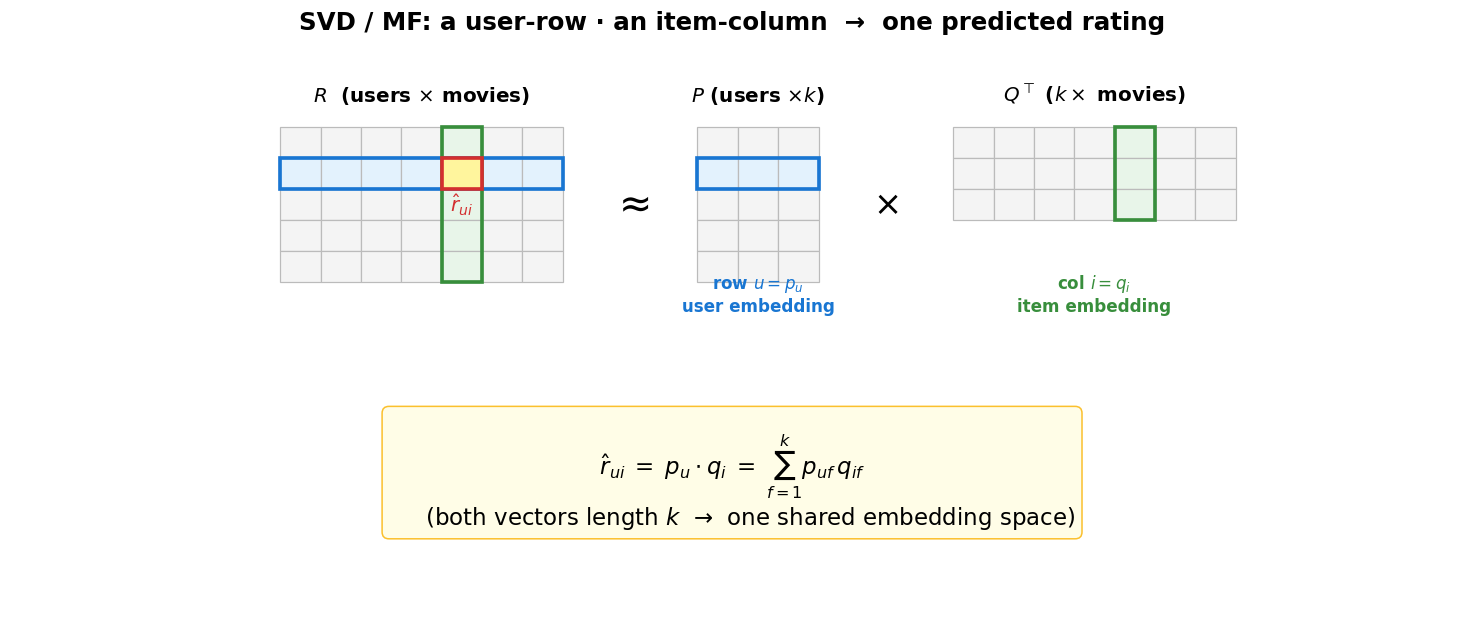

In [3]:
# A user-row times an item-column gives ONE cell. Both vectors live in the same k-dim space.
fig, ax = plt.subplots(figsize=(13.5, 6.0)); ax.axis('off')
ax.set_xlim(0, 15); ax.set_ylim(0, 8)
m, n, k = 5, 7, 3
cw = 0.42
u_hi, i_hi = 1, 4                                  # highlighted user-row / item-col
ry = 6.8                                           # top edge of every grid
yc = ry - m*cw/2                                   # vertical centre of the m-row grids (for operators)

def grid(x0, nr, nc, hi_row=None, hi_col=None, rc=BLUE, cc=GREEN):
    for r in range(nr):
        for c in range(nc):
            fc = '#f4f4f4'
            if hi_row is not None and r == hi_row: fc = '#e3f2fd'
            if hi_col is not None and c == hi_col: fc = '#e8f5e9'
            ax.add_patch(Rectangle((x0+c*cw, ry-(r+1)*cw), cw, cw,
                                   facecolor=fc, edgecolor='#bbb', lw=0.8))
    if hi_row is not None:
        ax.add_patch(Rectangle((x0, ry-(hi_row+1)*cw), nc*cw, cw, fill=False, ec=rc, lw=2.4))
    if hi_col is not None:
        ax.add_patch(Rectangle((x0+hi_col*cw, ry-nr*cw), cw, nr*cw, fill=False, ec=cc, lw=2.4))

# centred row:  R  ≈  P  ×  Qᵀ
rx = 2.8
px = rx + n*cw + 1.4
qx = px + k*cw + 1.4

# R (users x movies) with the target cell starred
grid(rx, m, n, hi_row=u_hi, hi_col=i_hi)
ax.add_patch(Rectangle((rx+i_hi*cw, ry-(u_hi+1)*cw), cw, cw,
                       facecolor='#fff59d', edgecolor=RED, lw=2.4, zorder=4))
ax.text(rx+n*cw/2, ry+0.35, r'$R$  (users $\times$ movies)', ha='center', fontweight='bold')
ax.text(rx+i_hi*cw+cw/2, ry-(u_hi+1)*cw-0.32, r'$\hat r_{ui}$', ha='center', color=RED, fontweight='bold')

ax.text(rx+n*cw+0.7, yc, r'$\approx$', fontsize=26, ha='center', va='center')

# P (users x k) -- highlight row u (user embedding)
grid(px, m, k, hi_row=u_hi)
ax.text(px+k*cw/2, ry+0.35, r'$P$ (users $\times k$)', ha='center', fontweight='bold')
ax.text(px+k*cw/2, ry-m*cw-0.4, r'row $u=p_u$' '\n' 'user embedding', ha='center',
        color=BLUE, fontweight='bold', fontsize=11)

ax.text(px+k*cw+0.7, yc, r'$\times$', fontsize=22, ha='center', va='center')

# Qᵀ (k x movies) -- highlight col i (item embedding)
grid(qx, k, n, hi_col=i_hi)
ax.text(qx+n*cw/2, ry+0.35, r'$Q^{\top}$ ($k \times$ movies)', ha='center', fontweight='bold')
ax.text(qx+n*cw/2, ry-m*cw-0.4, r'col $i=q_i$' '\n' 'item embedding', ha='center',
        color=GREEN, fontweight='bold', fontsize=11)

ax.text(7.5, 1.4,
        r'$\hat r_{ui}\;=\;p_u\cdot q_i\;=\;\sum_{f=1}^{k} p_{uf}\,q_{if}$'
        '\n     (both vectors length $k$  →  one shared embedding space)',
        ha='center', fontsize=15,
        bbox=dict(boxstyle='round', fc='#fffde7', ec='#fbc02d'))
ax.set_title('SVD / MF: a user-row · an item-column  →  one predicted rating', fontweight='bold')
plt.tight_layout(); plt.show()

> **Details.** Row $u$ of $P$ is the user vector $p_u$; column $i$ of $Q^{\mathsf T}$ is the item vector
> $q_i$. Both have length $k$, so users and movies are points in the **same space**.
> $R$ is $m\times n$, so its rank is at most $\min(m,n)$: $\Sigma$ holds at most $\min(m,n)$ singular
> values and $k$ cannot exceed that.

## Similar Vectors, Similar Entries

- Cosine similarity (Session 7) now applies to **learned** vectors.
- Close **movie** vectors → similar movies.
- Close **user** vectors → similar taste.

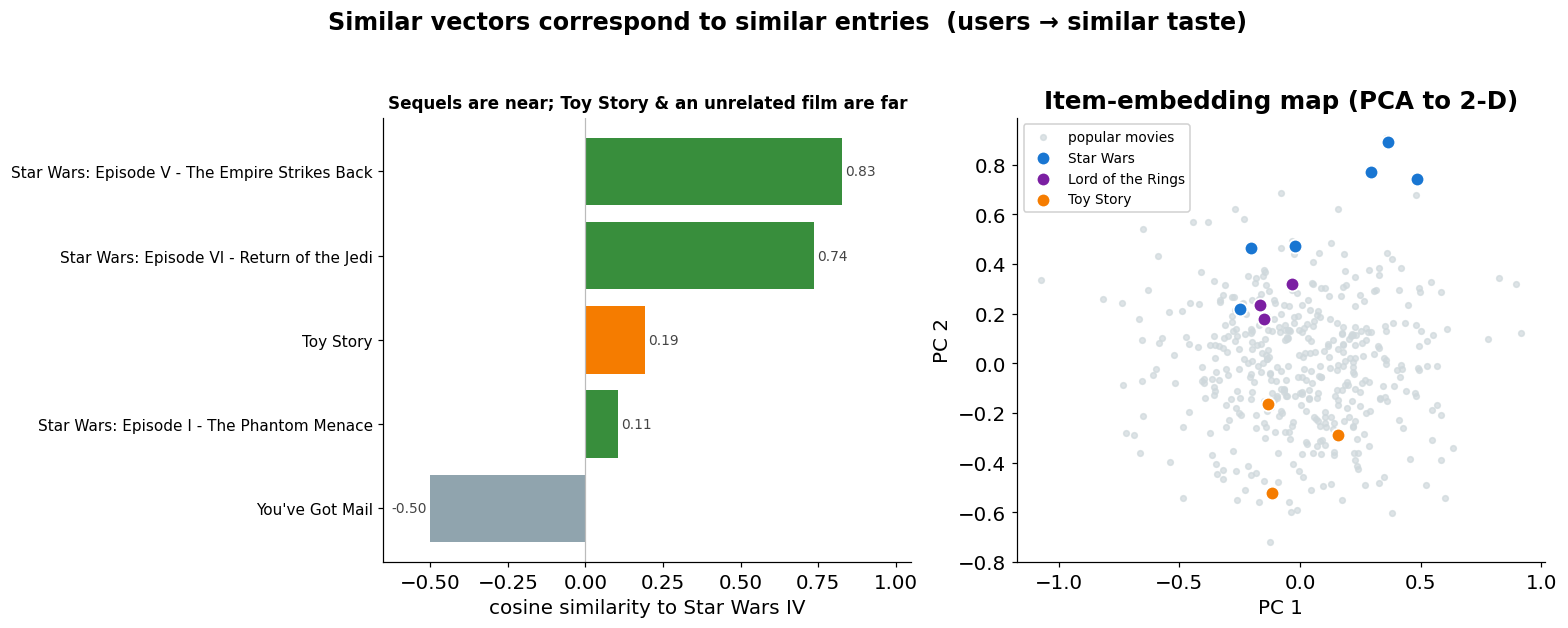

In [4]:
# Embeddings -> similarity. Left: cosine of Star Wars IV vs a curated set. Right: a 2-D map of the item space.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14.5, 5.6))

# --- left: cosine to Star Wars IV — its sequels (near) vs Toy Story and an unrelated film (far) ---
m0, all_nbrs = mf_neighbors('Star Wars: Episode IV', k=len(mf_Qp))   # every popular movie, sorted by cosine
sim_of = {mid: s for mid, s in all_nbrs}
sequels = [(mid, s) for mid, s in all_nbrs                            # a few Star Wars sequels (highest)
           if rc_title[mid].startswith('Star Wars') and mid != m0][:3]
toy_id  = mf_ids('Toy Story')[0]                                      # different franchise, for contrast
far_id, far_s = all_nbrs[-1]                                          # the single most DISSIMILAR popular movie
picks = sequels + [(toy_id, sim_of[toy_id]), (far_id, far_s)]
picks = sorted(picks, key=lambda p: p[1])                            # ascending -> highest bar on top
def _bar_col(mid):
    t = rc_title[mid]
    return GREEN if t.startswith('Star Wars') else ORANGE if t.startswith('Toy Story') else '#90a4ae'
labels = [rc_title[mid].split(' (')[0] for mid, _ in picks]
sims   = [s for _, s in picks]
axL.barh(range(len(sims)), sims, color=[_bar_col(mid) for mid, _ in picks])
axL.set_yticks(range(len(labels))); axL.set_yticklabels(labels, fontsize=10)
for y, s in enumerate(sims):
    axL.text(s + 0.01 if s >= 0 else s - 0.01, y, f'{s:.2f}', va='center',
             ha='left' if s >= 0 else 'right', fontsize=9, color='#444')
axL.set_xlabel('cosine similarity to Star Wars IV'); axL.set_xlim(min(0, min(sims)) - 0.15, 1.05)
axL.axvline(0, color='#bbb', lw=0.8)
axL.set_title('Sequels are near; Toy Story & an unrelated film are far', fontweight='bold', fontsize=11)
axL.spines[['top','right']].set_visible(False)

# --- right: 2-D PCA map, a few franchises coloured ---
axR.scatter(mf_xy.x, mf_xy.y, s=14, color='#cfd8dc', alpha=0.7, label='popular movies')
for name, col in [('Star Wars', BLUE), ('Lord of the Rings', PURPLE), ('Toy Story', ORANGE)]:
    pts = mf_xy.loc[mf_ids(name)]
    axR.scatter(pts.x, pts.y, s=80, color=col, edgecolor='white', lw=1.2, zorder=3, label=name)
axR.set_title('Item-embedding map (PCA to 2-D)', fontweight='bold')
axR.set_xlabel('PC 1'); axR.set_ylabel('PC 2')
axR.legend(loc='best', fontsize=9, framealpha=0.9)
axR.spines[['top','right']].set_visible(False)

fig.suptitle('Similar vectors correspond to similar entries  (users → similar taste)',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

> *Star Wars IV*'s nearest neighbours are its own sequels; *Toy Story* and an unrelated film
> sit far away. Nearest-neighbour search over these vectors drives the rest of Session 9.

## A neural "layer" is just a matrix multiply (then a bend)

Before **AutoRec** (an autoencoder) one idea makes every neural net readable: a layer takes its input
**vector**, **multiplies by a weight matrix**, adds a bias, then applies a non-linearity $\sigma$.

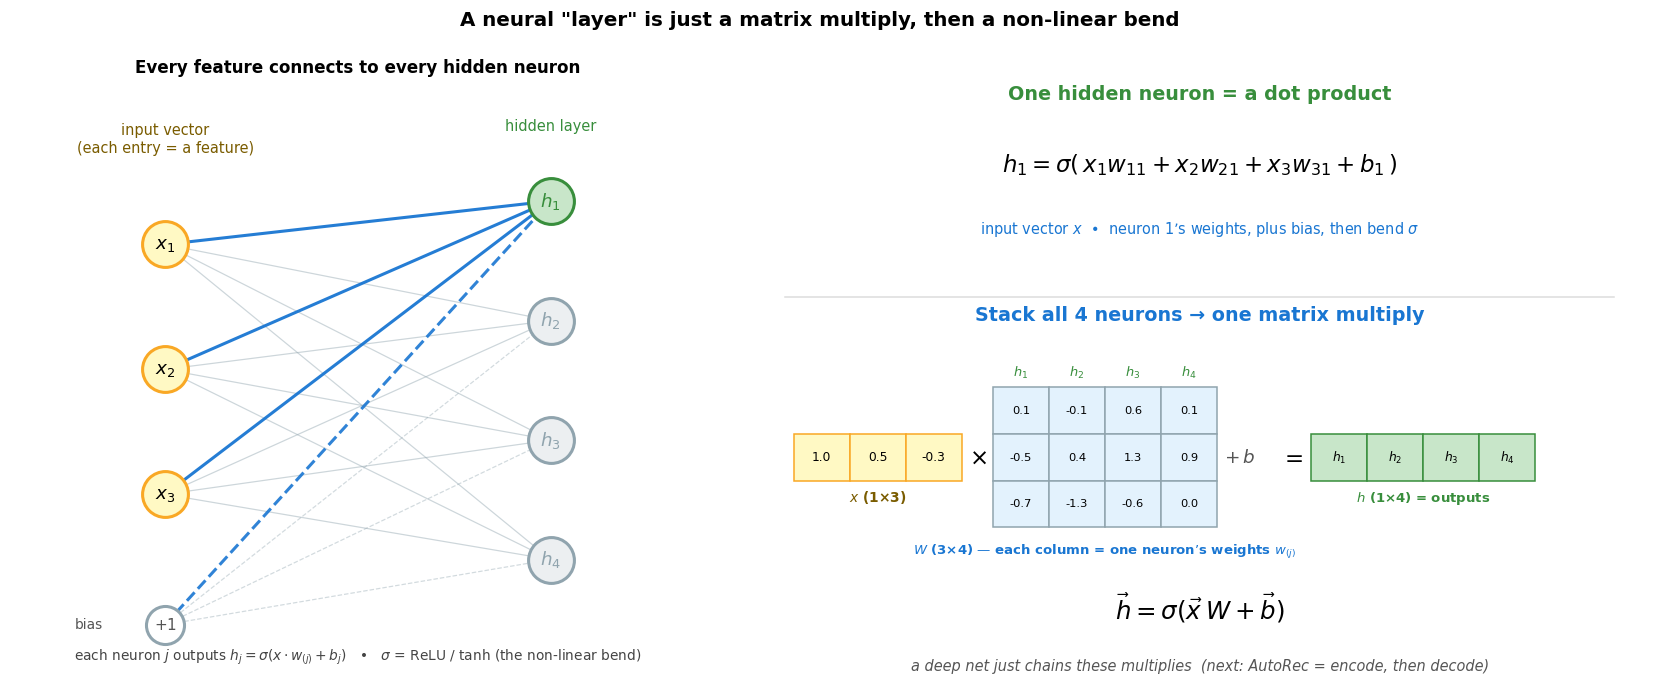

In [5]:
# Left: the neuron graph (every feature -> every hidden neuron). Right: the math — one neuron's dot
# product, then the whole layer as a single matrix multiply  h = σ(xW + b).
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15.5, 6.4), gridspec_kw={'width_ratios': [1.0, 1.3]})
rng = np.random.default_rng(0)
W = rng.normal(size=(3, 4)).round(1)        # 3 features -> 4 hidden neurons;  h = xW + b
NB, NG, NO, NY = '#1976d2', '#388e3c', '#f9a825', '#90a4ae'

# ---- left: neuron graph; highlight the edges feeding h1 (the neuron the math expands) ----
xin = [(0.0, y) for y in (0.78, 0.55, 0.32)]
bias = (0.0, 0.08)
hout = [(1.0, y) for y in (0.86, 0.64, 0.42, 0.20)]
for i, (xi, yi) in enumerate(xin):
    for j, (xj, yj) in enumerate(hout):
        hot = (j == 0)
        axL.plot([xi, xj], [yi, yj], color=(NB if hot else NY),
                 lw=2.0 if hot else 0.8, alpha=0.95 if hot else 0.45, zorder=1)
for j, (xj, yj) in enumerate(hout):
    hot = (j == 0)
    axL.plot([bias[0], xj], [bias[1], yj], color=(NB if hot else NY),
             lw=2.0 if hot else 0.8, alpha=0.9 if hot else 0.4, ls='--', zorder=1)
for idx, (x, y) in enumerate(xin):
    axL.scatter([x], [y], s=900, color='#fff9c4', edgecolor=NO, lw=2, zorder=3)
    axL.text(x, y, f'$x_{idx+1}$', ha='center', va='center', zorder=4, fontsize=12)
axL.scatter(*bias, s=620, color='white', edgecolor=NY, lw=2, zorder=3)
axL.text(bias[0], bias[1], '$+1$', ha='center', va='center', zorder=4, fontsize=10, color='#555')
axL.text(bias[0]-0.16, bias[1], 'bias', ha='right', va='center', fontsize=9, color='#555')
for j, (x, y) in enumerate(hout):
    fc = '#c8e6c9' if j == 0 else '#eceff1'
    ec = NG if j == 0 else NY
    axL.scatter([x], [y], s=900, color=fc, edgecolor=ec, lw=2, zorder=3)
    axL.text(x, y, f'$h_{j+1}$', ha='center', va='center', zorder=4, fontsize=12, color=ec)
axL.text(0.0, 0.95, 'input vector\n(each entry = a feature)', ha='center', fontsize=9.5, color='#7a5c00')
axL.text(1.0, 0.99, 'hidden layer', ha='center', fontsize=9.5, color=NG)
axL.text(0.5, 0.015, r'each neuron $j$ outputs $h_j=\sigma(x\cdot w_{(j)}+b_j)$   •   $\sigma$ = ReLU / tanh (the non-linear bend)',
         ha='center', fontsize=9, color='#444')
axL.set_xlim(-0.4, 1.4); axL.set_ylim(-0.02, 1.08); axL.axis('off')
axL.set_title('Every feature connects to every hidden neuron', fontsize=11, fontweight='bold')

# ---- right: math — one neuron's dot product (top), the whole layer as a matrix multiply (bottom) ----
axR.axis('off'); axR.set_xlim(0, 1); axR.set_ylim(0, 1)
axR.text(0.5, 0.97, 'One hidden neuron = a dot product', ha='center', fontsize=12.5, fontweight='bold', color=NG)
axR.text(0.5, 0.85, r'$h_1=\sigma(\,x_1 w_{11}+x_2 w_{21}+x_3 w_{31}+b_1\,)$', ha='center', fontsize=15)
axR.text(0.5, 0.745, 'input vector $x$  •  neuron 1’s weights, plus bias, then bend $\\sigma$',
         ha='center', fontsize=9.5, color=NB)
axR.plot([0.04, 0.96], [0.64, 0.64], color='#ddd', lw=1)
axR.text(0.5, 0.60, 'Stack all 4 neurons → one matrix multiply', ha='center', fontsize=12.5, fontweight='bold', color=NB)
cw, ch = 0.062, 0.078
def cellrow(x0, y, vals, fc, ec, labels=None):
    for c, v in enumerate(vals):
        axR.add_patch(plt.Rectangle((x0+c*cw, y), cw, ch, facecolor=fc, edgecolor=ec, lw=1))
        axR.text(x0+c*cw+cw/2, y+ch/2, labels[c] if labels else f'{v:.1f}', ha='center', va='center', fontsize=8)
    return x0+len(vals)*cw
def cellgrid(x0, ytop, mat, fc, ec):
    for r, row in enumerate(mat):
        for c, v in enumerate(row):
            axR.add_patch(plt.Rectangle((x0+c*cw, ytop-r*ch), cw, ch, facecolor=fc, edgecolor=ec, lw=1))
            axR.text(x0+c*cw+cw/2, ytop-r*ch+ch/2, f'{v:.1f}', ha='center', va='center', fontsize=7.5)
    return x0+len(mat[0])*cw
ytopW = 0.41
yc = ytopW - ch            # centre row aligns x and h with W's middle row
x0 = 0.05
xe = cellrow(x0, yc, [1.0, 0.5, -0.3], '#fff9c4', NO)
axR.text(x0+1.5*cw, yc-0.035, r'$x$ (1×3)', ha='center', fontsize=9, color='#7a5c00', fontweight='bold')
axR.text(xe+0.008, yc+ch/2, r'$\times$', fontsize=15, va='center')
wx = xe+0.035
# one column per neuron -> one output; green headers tie each column to its h_j
for c in range(4):
    axR.text(wx+c*cw+cw/2, ytopW+ch+0.012, f'$h_{c+1}$', ha='center', va='bottom', fontsize=8.5, color=NG, fontweight='bold')
we = cellgrid(wx, ytopW, W, '#e3f2fd', '#90a4ae')
axR.text(we+0.008, yc+ch/2, r'$+\,b$', fontsize=12, va='center', color='#555')
axR.text(we+0.07, yc+ch/2, r'$=$', fontsize=15, va='center')
hx = we+0.105
cellrow(hx, yc, [0, 0, 0, 0], '#c8e6c9', NG, labels=[f'$h_{i+1}$' for i in range(4)])
axR.text(hx+2*cw, yc-0.035, r'$h$ (1×4) = outputs', ha='center', fontsize=8.7, color=NG, fontweight='bold')
# clarify what the blue columns ARE (weights, not the outputs)
axR.text(wx+2*cw, ytopW-2*ch-0.045, r'$W$ (3×4) — each column = one neuron’s weights $w_{(j)}$',
         ha='center', fontsize=8.7, color=NB, fontweight='bold')
axR.text(0.5, 0.10, r'$\vec h=\sigma(\vec x\,W+\vec b)$', ha='center', fontsize=16)
axR.text(0.5, 0.015, 'a deep net just chains these multiplies  (next: AutoRec = encode, then decode)',
         ha='center', fontsize=9.5, color='#555', style='italic')
fig.suptitle('A neural "layer" is just a matrix multiply, then a non-linear bend',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

- The **input is a vector** — each entry is one **feature**, drawn as a neuron.
- Each **hidden neuron** is a **dot product** of the input with its own weights, plus a bias, then $\sigma$:
  $h_1=\sigma(x\cdot w_{(1)}+b_1)$.
- **Stack** every neuron's weights as columns of a matrix $W$ → the whole layer is one **matrix multiply**:
  $\vec h=\sigma(\vec x\,W+\vec b)$.
- A deep net just **chains** these multiplies.

## Autoencoder (AutoRec): Architecture

- Input = a movie's **rating column** (length = #users).
- **Encoder** down-projects → **bottleneck** ($k$ numbers).
- **Decoder** up-projects → reconstructed column.

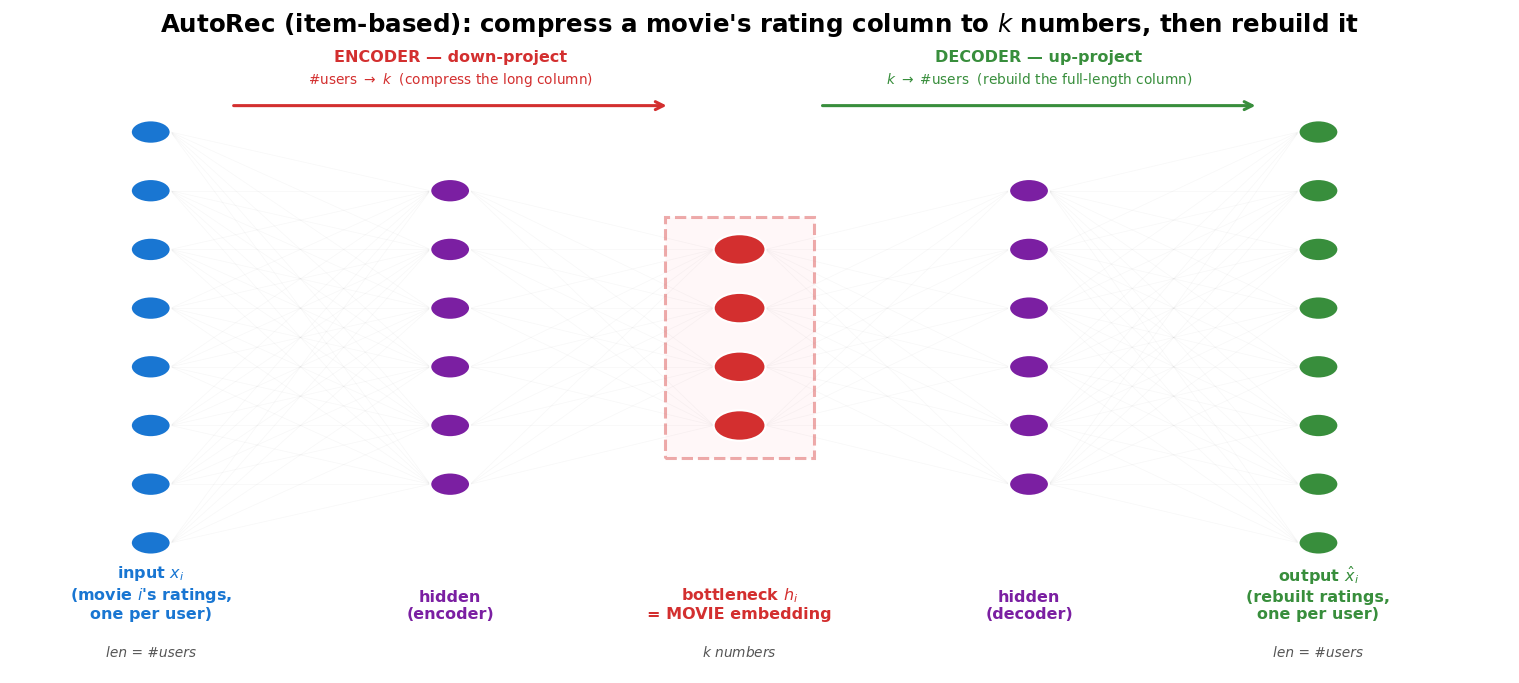

In [6]:
# AutoRec (item-based): movie's rating column -> down-project -> bottleneck -> up-project -> rebuilt column.
fig, ax = plt.subplots(figsize=(14, 6.4)); ax.axis('off')
ax.set_xlim(0, 15); ax.set_ylim(-1.8, 8.95)
layers = [('input $x_i$\n(movie $i$\'s ratings,\none per user)', 1.4,
           [0.4,1.4,2.4,3.4,4.4,5.4,6.4,7.4], BLUE, 'len = #users'),
          ('hidden\n(encoder)', 4.4, [1.4,2.4,3.4,4.4,5.4,6.4], PURPLE, ''),
          ('bottleneck $h_i$\n= MOVIE embedding', 7.3, [2.4,3.4,4.4,5.4], RED, '$k$ numbers'),
          ('hidden\n(decoder)', 10.2, [1.4,2.4,3.4,4.4,5.4,6.4], PURPLE, ''),
          ('output $\\hat x_i$\n(rebuilt ratings,\none per user)', 13.1,
           [0.4,1.4,2.4,3.4,4.4,5.4,6.4,7.4], GREEN, 'len = #users')]
for idx,(name,x,ys,col,sub) in enumerate(layers):
    r = 0.20 if len(ys) > 5 else 0.26
    for y in ys:
        ax.add_patch(plt.Circle((x,y), r, facecolor=col, edgecolor='white', lw=1.4, zorder=3))
    ax.text(x, -0.9, name, ha='center', fontsize=10.5, fontweight='bold', color=col)
    if sub: ax.text(x, -1.55, sub, ha='center', fontsize=9, color='#555', style='italic')
    if idx < len(layers)-1:
        _, nx, nys, _, _ = layers[idx+1]; nr = 0.20 if len(nys) > 5 else 0.26
        for y in ys:
            for ny in nys:
                ax.plot([x+r, nx-nr], [y, ny], color='gray', alpha=0.06, lw=0.5)
# down- / up-projection labels — plain language: shrink #users -> k, then grow k -> #users
ax.annotate('', xy=(6.6, 7.85), xytext=(2.2, 7.85),
            arrowprops=dict(arrowstyle='->', color=RED, lw=2))
ax.text(4.4, 8.6, 'ENCODER — down-project', ha='center', fontsize=10.5, color=RED, fontweight='bold')
ax.text(4.4, 8.22, '#users $\\rightarrow$ $k$  (compress the long column)', ha='center', fontsize=9, color=RED)
ax.annotate('', xy=(12.5, 7.85), xytext=(8.1, 7.85),
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=2))
ax.text(10.3, 8.6, 'DECODER — up-project', ha='center', fontsize=10.5, color=GREEN, fontweight='bold')
ax.text(10.3, 8.22, '$k$ $\\rightarrow$ #users  (rebuild the full-length column)', ha='center', fontsize=9, color=GREEN)
ax.add_patch(Rectangle((6.55, 1.85), 1.5, 4.1, facecolor='#ffebee',
                       edgecolor=RED, lw=2, ls='--', alpha=0.4, zorder=1))
ax.set_title('AutoRec (item-based): compress a movie\'s rating column to $k$ numbers, then rebuild it',
             fontweight='bold')
plt.tight_layout(); plt.show()

> The **encoder down-projects** the rating column from #users numbers down to just $k$ — the bottleneck (the
> movie embedding). The **decoder up-projects** those $k$ numbers back up to #users, rebuilding the column.
> (Item-based; AutoRec stores no movie vector — it computes one each time it runs the column through.)

## AutoRec: Computed vs. Learned Embeddings

- **Bottleneck $h_i$** = movie embedding — **computed** by the encoder.
- **Decoder row $V_u$** = user embedding — a **learned** weight.
- $\hat r_{ui} = h_i \cdot V_u$ — the same dot product as MF.

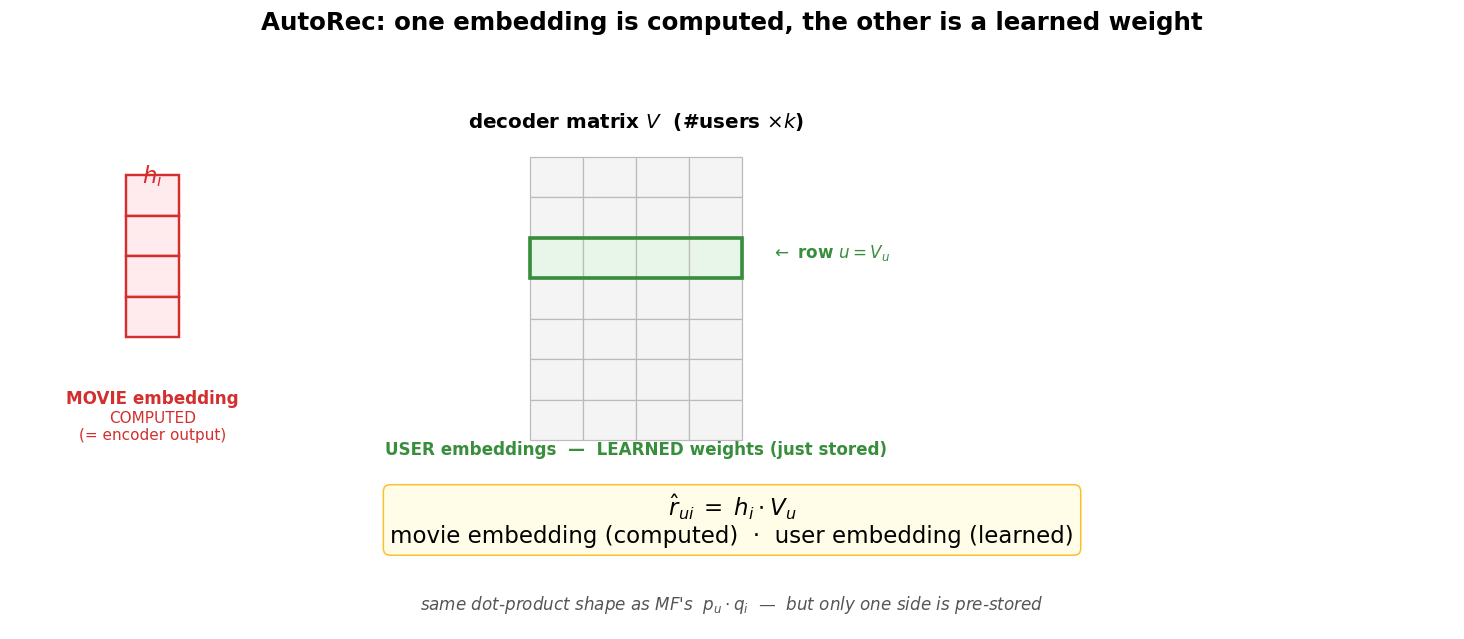

Symmetric note: a USER-based AutoRec flips it — feed a user's rating ROW (length = #movies),
 the bottleneck becomes the USER embedding, and the decoder rows become MOVIE embeddings.


In [7]:
# Zoom: bottleneck = COMPUTED movie embedding; a decoder ROW = a LEARNED user embedding. r̂ = their dot.
fig, ax = plt.subplots(figsize=(13.5, 6.0)); ax.axis('off')
ax.set_xlim(0, 15); ax.set_ylim(0, 8)

# bottleneck h_i (computed)
bx, by, k = 1.2, 5.6, 4
for j in range(k):
    ax.add_patch(Rectangle((bx, by-j*0.55), 0.55, 0.55, facecolor='#ffebee', edgecolor=RED, lw=1.6))
ax.text(bx+0.275, by+0.45, r'$h_i$', ha='center', color=RED, fontsize=15, fontweight='bold')
ax.text(bx+0.275, by-k*0.55-0.35, 'MOVIE embedding', ha='center', color=RED, fontweight='bold', fontsize=11)
ax.text(bx+0.275, by-k*0.55-0.85, 'COMPUTED\n(= encoder output)', ha='center', color=RED, fontsize=10)

# decoder matrix V (learned) -- rows = users
vx, vy, vr, vc = 5.4, 6.4, 7, k
u_hi = 2
for r in range(vr):
    for c in range(vc):
        fc = '#e8f5e9' if r == u_hi else '#f4f4f4'
        ax.add_patch(Rectangle((vx+c*0.55, vy-(r+1)*0.55), 0.55, 0.55,
                               facecolor=fc, edgecolor='#bbb', lw=0.8))
ax.add_patch(Rectangle((vx, vy-(u_hi+1)*0.55), vc*0.55, 0.55, fill=False, ec=GREEN, lw=2.4))
ax.text(vx+vc*0.55/2, vy+0.4, r'decoder matrix $V$  (#users $\times k$)', ha='center', fontweight='bold')
ax.text(vx+vc*0.55+0.3, vy-(u_hi+0.5)*0.55, r'$\leftarrow$ row $u = V_u$', ha='left',
        color=GREEN, fontweight='bold', fontsize=11)
ax.text(vx+vc*0.55/2, vy-vr*0.55-0.2, 'USER embeddings  —  LEARNED weights (just stored)',
        ha='center', color=GREEN, fontweight='bold', fontsize=11)

# the dot product result
ax.text(7.5, 1.15,
        r'$\hat r_{ui}\;=\;h_i \cdot V_u$' '\n'
        r'movie embedding (computed)  ·  user embedding (learned)',
        ha='center', fontsize=15, bbox=dict(boxstyle='round', fc='#fffde7', ec='#fbc02d'))
ax.text(7.5, 0.25, 'same dot-product shape as MF\'s  $p_u \\cdot q_i$  —  but only one side is pre-stored',
        ha='center', fontsize=11, color='#555', style='italic')
ax.set_title('AutoRec: one embedding is computed, the other is a learned weight', fontweight='bold')
plt.tight_layout(); plt.show()
print('Symmetric note: a USER-based AutoRec flips it — feed a user\'s rating ROW (length = #movies),'
      '\n the bottleneck becomes the USER embedding, and the decoder rows become MOVIE embeddings.')

## SVD vs. AutoRec: Calculated vs. Learned

- Same destination: every user and movie is a vector in one shared space; a rating is their dot product.
- The difference is **how each vector is produced**.

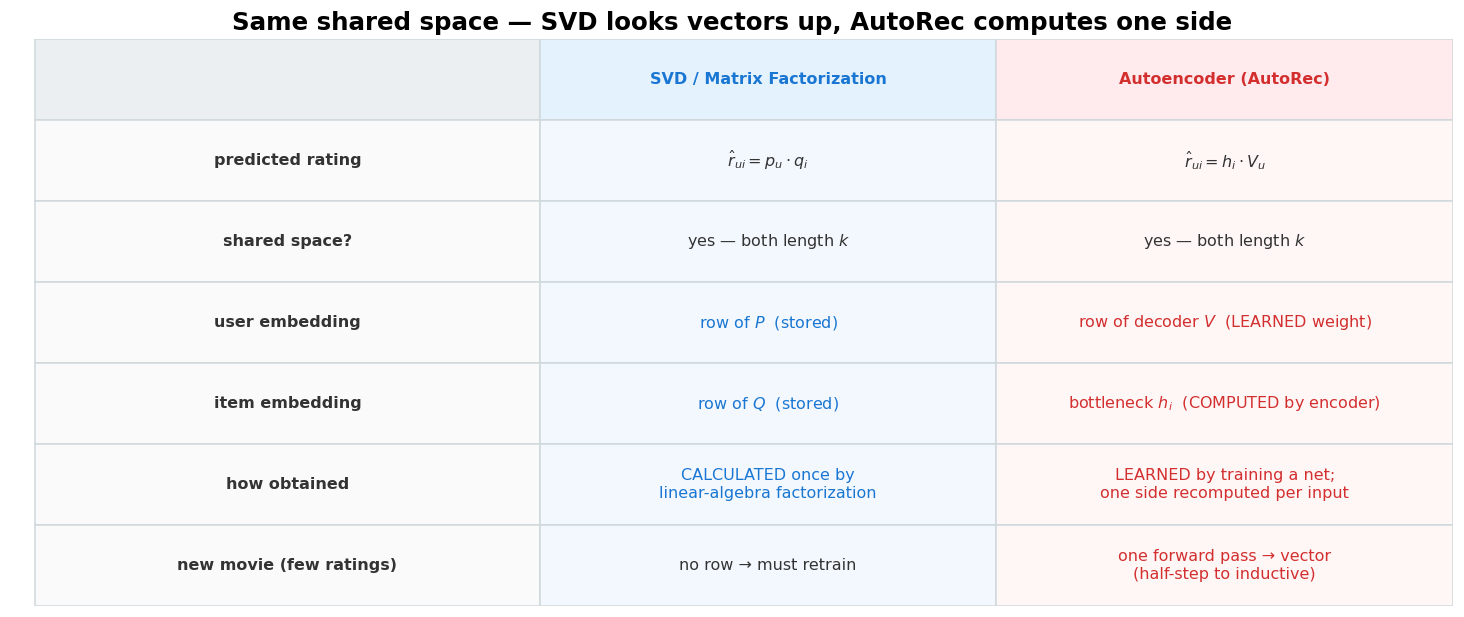

In [8]:
# Comparison table: SVD/MF vs AutoRec — what the embedding is and how you get it.
fig, ax = plt.subplots(figsize=(13.5, 5.8)); ax.axis('off')
ax.set_xlim(0, 12); ax.set_ylim(0, 10)
rows = [
    ('',                         'SVD / Matrix Factorization', 'Autoencoder (AutoRec)'),
    ('predicted rating',         r'$\hat r_{ui}=p_u\cdot q_i$', r'$\hat r_{ui}=h_i\cdot V_u$'),
    ('shared space?',            'yes — both length $k$',       'yes — both length $k$'),
    ('user embedding',           'row of $P$  (stored)',        'row of decoder $V$  (LEARNED weight)'),
    ('item embedding',           'row of $Q$  (stored)',        'bottleneck $h_i$  (COMPUTED by encoder)'),
    ('how obtained',             'CALCULATED once by\nlinear-algebra factorization',
                                 'LEARNED by training a net;\none side recomputed per input'),
    ('new movie (few ratings)',  'no row → must retrain',       'one forward pass → vector\n(half-step to inductive)'),
]
nC = 3; colx = [0.2, 4.4, 8.2]; colw = [4.2, 3.8, 3.8]
rh = 10/len(rows)
for ri,(a,b,c) in enumerate(rows):
    y = 10-(ri+1)*rh
    head = (ri == 0)
    for ci,(txt,x,w) in enumerate(zip((a,b,c), colx, colw)):
        if head:
            fc = '#eceff1' if ci==0 else ('#e3f2fd' if ci==1 else '#ffebee')
        else:
            fc = '#fafafa' if ci==0 else ('#f3f8fe' if ci==1 else '#fff6f6')
        ax.add_patch(Rectangle((x, y), w, rh, facecolor=fc, edgecolor='#cfd8dc', lw=1))
        fw = 'bold' if (head or ci==0) else 'normal'
        col = '#333'
        if not head and ci==1 and ('stored' in txt or 'CALCULATED' in txt): col = BLUE
        if not head and ci==2 and ('LEARNED' in txt or 'COMPUTED' in txt or 'forward' in txt): col = RED
        ax.text(x+w/2, y+rh/2, txt, ha='center', va='center', fontsize=10.5,
                fontweight=fw, color=(BLUE if head and ci==1 else RED if head and ci==2 else col))
ax.set_title('Same shared space — SVD looks vectors up, AutoRec computes one side',
             fontweight='bold')
plt.tight_layout(); plt.show()

> SVD looks both vectors up (calculated once by factorization); AutoRec computes one side with
> the encoder and stores the other, so a new movie gets a vector in a single forward pass.

## word2vec (skip-gram): predict a word's neighbours

So far every embedding came from **ratings**. To embed things *nobody has rated yet*, we turn to
**text** — starting with the simplest unit: the **word**.

- The **objective**: from the **center word**, predict each surrounding **context word**.
- Slide a window over plain text → that gives the (input → output) training pairs.
- The running text is its **own supervision** — no human labels.

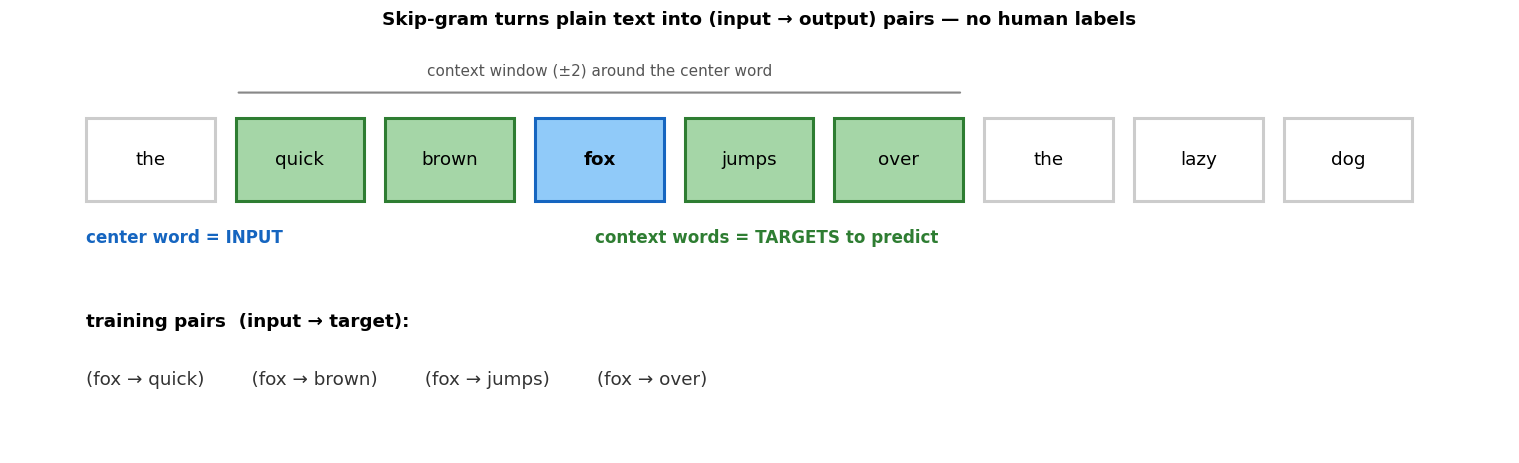

In [9]:
# What goes IN and OUT: slide a window over text; (center word -> each context word) are the training pairs.
fig, ax = plt.subplots(figsize=(14, 4.4)); ax.axis('off'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
sent = ['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']
center, win = 3, 2
x0, w = 0.05, 0.10
for i, wd in enumerate(sent):
    x = x0 + i * w
    inwin = (abs(i - center) <= win) and (i != center)
    fc, ec = ('#90caf9', '#1565c0') if i == center else (('#a5d6a7', '#2e7d32') if inwin else ('white', '#cccccc'))
    ax.add_patch(plt.Rectangle((x, 0.60), w * 0.86, 0.20, facecolor=fc, edgecolor=ec, lw=2))
    ax.text(x + w * 0.43, 0.70, wd, ha='center', va='center',
            fontsize=12, fontweight='bold' if i == center else 'normal')
lo, hi = x0 + (center - win) * w, x0 + (center + win) * w + w * 0.86
ax.annotate('', xy=(hi, 0.86), xytext=(lo, 0.86), arrowprops=dict(arrowstyle='-', lw=1.4, color='#888'))
ax.text((lo + hi) / 2, 0.90, 'context window (±2) around the center word', ha='center', fontsize=10, color='#555')
ax.text(x0, 0.50, 'center word = INPUT', color='#1565c0', fontsize=11, fontweight='bold')
ax.text(x0 + 0.34, 0.50, 'context words = TARGETS to predict', color='#2e7d32', fontsize=11, fontweight='bold')
pairs = [f'(fox → {sent[j]})' for j in range(center - win, center + win + 1) if j != center]
ax.text(x0, 0.30, 'training pairs  (input → target):', fontsize=12, fontweight='bold')
ax.text(x0, 0.16, '        '.join(pairs), fontsize=12, color='#333')
ax.set_title('Skip-gram turns plain text into (input → output) pairs — no human labels',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Turn that objective into a network

- Feed the center word as a **one-hot** vector ($V = 10{,}000$); train a small **2-matrix net** to
  predict its context words.
- The matrix that builds the hidden layer **is** the embedding table — that is the part we keep.

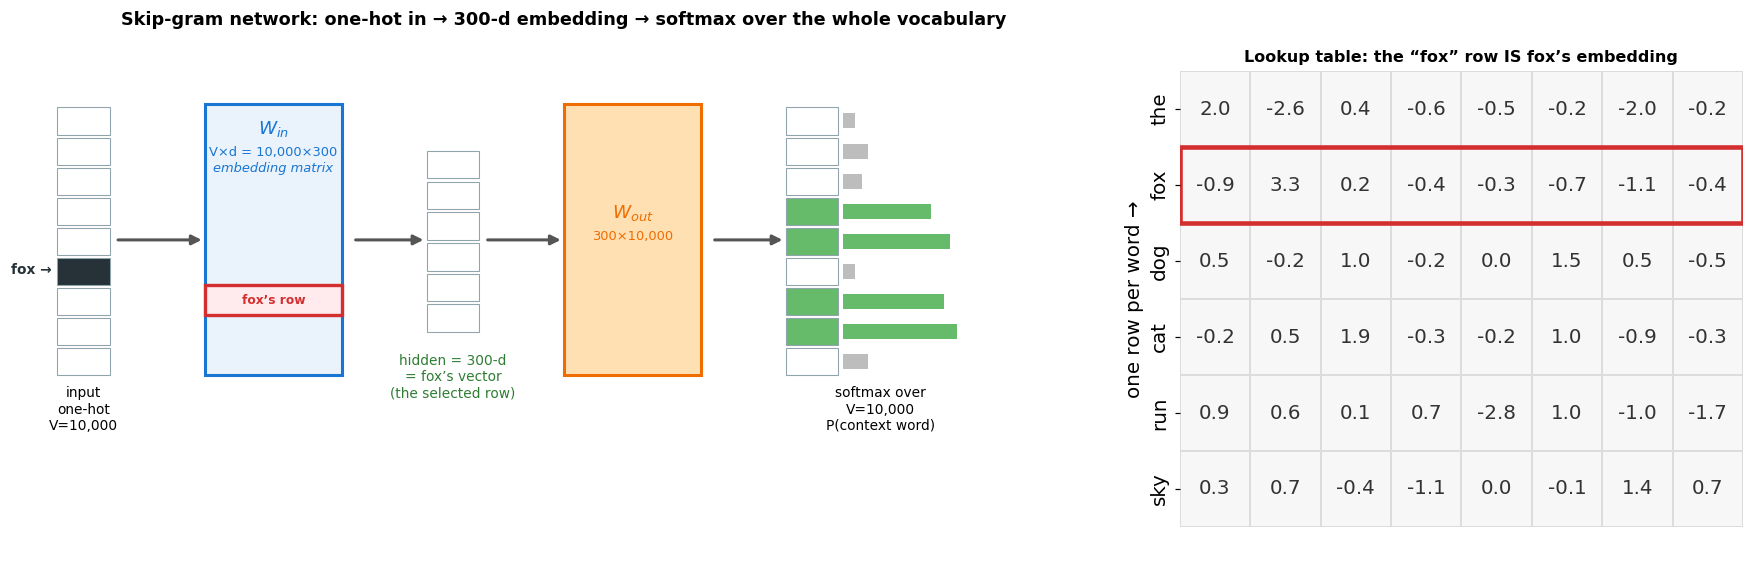

one-hot · W_in selects a row — so each of the V rows of W_in is one word’s d-dim embedding.


In [10]:
# The network with REAL shapes. Left: the pipeline. Right: one-hot × W_in just selects a row = the embedding.
import seaborn as sns
fig = plt.figure(figsize=(16, 5.6))
axP = fig.add_axes([0.01, 0.04, 0.60, 0.88]); axP.axis('off'); axP.set_xlim(0, 1); axP.set_ylim(0, 1)

def stack(ax, x, yc, h, n, cw=0.05, dark=None, green=None, bars=None):
    y0 = yc - h / 2; ch = h / n
    for k in range(n):
        color = 'white'
        if dark is not None and k == dark: color = '#263238'      # the single 1 (fox)
        if green is not None and k in green: color = '#66bb6a'    # predicted context words
        ax.add_patch(plt.Rectangle((x, y0 + k * ch), cw, ch * 0.9, facecolor=color, edgecolor='#90a4ae', lw=0.7))
        if bars is not None:
            ax.add_patch(plt.Rectangle((x + cw + 0.004, y0 + k * ch + ch * 0.2), bars[k] * 0.12, ch * 0.5,
                                       facecolor='#66bb6a' if (green and k in green) else '#bdbdbd', edgecolor='none'))
    return x + cw

def blk(ax, x, yc, w, h, fc, ec):
    ax.add_patch(plt.Rectangle((x, yc - h / 2), w, h, facecolor=fc, edgecolor=ec, lw=2))

def arr(ax, x0, x1, y=0.62):
    ax.annotate('', xy=(x1, y), xytext=(x0, y), arrowprops=dict(arrowstyle='-|>', lw=2, color='#555'))

yc = 0.62
e = stack(axP, 0.02, yc, 0.5, 9, dark=3)                       # one-hot input (fox = row 3)
axP.text(0.045, 0.27, 'input\none-hot\nV=10,000', ha='center', fontsize=9)
axP.text(0.015, (yc - 0.25) + 3.5 * (0.5 / 9), 'fox →', ha='right', va='center',
         fontsize=9, fontweight='bold', color='#263238')      # points at the single 1
arr(axP, e + 0.005, 0.16)
# W_in block: labels pinned to the TOP, the highlighted 'fox' row lower down so they never overlap
blk(axP, 0.16, yc, 0.13, 0.5, '#eaf2fb', '#1976d2')
axP.text(0.225, 0.815, '$W_{in}$', ha='center', fontsize=12, fontweight='bold', color='#1976d2')
axP.text(0.225, 0.775, 'V×d = 10,000×300', ha='center', fontsize=8.5, color='#1976d2')
axP.text(0.225, 0.745, 'embedding matrix', ha='center', fontsize=8.5, color='#1976d2', style='italic')
rowy = (yc - 0.25) + 2.0 * (0.5 / 9)
axP.add_patch(plt.Rectangle((0.16, rowy), 0.13, 0.5 / 9, facecolor='#ffebee', edgecolor='#d32f2f', lw=2.2))
axP.text(0.225, rowy + 0.5/18, 'fox’s row', ha='center', va='center', fontsize=8, color='#d32f2f', fontweight='bold')
arr(axP, 0.30, 0.37)
h2 = stack(axP, 0.37, yc, 0.34, 6)                             # hidden = the selected row (plain, no colour)
axP.text(0.395, 0.33, 'hidden = 300-d\n= fox’s vector\n(the selected row)', ha='center', fontsize=9, color='#2e7d32')
arr(axP, h2 + 0.005, 0.50)
blk(axP, 0.50, yc, 0.13, 0.5, '#ffe0b2', '#ef6c00')
axP.text(0.565, 0.66, '$W_{out}$', ha='center', fontsize=12, fontweight='bold', color='#ef6c00')
axP.text(0.565, 0.62, '300×10,000', ha='center', fontsize=8.5, color='#ef6c00')
arr(axP, 0.64, 0.71)
stack(axP, 0.71, yc, 0.5, 9, green=[1, 2, 4, 5], bars=[.2, .9, .8, .1, .85, .7, .15, .2, .1])  # softmax out
axP.text(0.80, 0.27, 'softmax over\nV=10,000\nP(context word)', ha='center', fontsize=9)
axP.set_title('Skip-gram network: one-hot in → 300-d embedding → softmax over the whole vocabulary',
              fontsize=11.5, fontweight='bold')

# right: the lookup-table zoom — plain cells (no colour map), real numbers, only fox's row highlighted
axL = fig.add_axes([0.66, 0.12, 0.32, 0.74])
rng = np.random.default_rng(3)
Wsmall = rng.normal(size=(6, 8)).round(1)
vocab = ['the', 'fox', 'dog', 'cat', 'run', 'sky']
sns.heatmap(np.full_like(Wsmall, 0.07), ax=axL, cmap='Greys', vmin=0, vmax=1, cbar=False,
            annot=Wsmall, fmt='.1f', annot_kws={'color': '#333'},
            linewidths=1, linecolor='#dcdcdc', yticklabels=vocab, xticklabels=False)
axL.add_patch(plt.Rectangle((0, 1), 8, 1, fill=False, edgecolor='#d32f2f', lw=3))   # 'fox' row
axL.set_title('Lookup table: the “fox” row IS fox’s embedding', fontsize=10.5, fontweight='bold')
axL.set_ylabel('one row per word →')
plt.show()
print('one-hot · W_in selects a row — so each of the V rows of W_in is one word’s d-dim embedding.')

- **$W_{in}$ — embedding matrix, $V\times d = 10{,}000\times 300$.** One-hot $\times\,W_{in}$ just
  **selects that word's row** — a **down-projection** $10{,}000 \rightarrow 300$. That row **is** the word's embedding.
- **Hidden = 300 numbers, no activation.** It is *not* a layer of neurons applying a non-linearity — it is
  purely the down-projected word (exactly like the autoencoder's bottleneck is the down-projected item).
- **$W_{out}$ — $d\times V = 300\times 10{,}000$.** **Up-projects** the 300-d embedding back to $10{,}000$
  scores; **softmax** → P(each word is a context word).
- Words sharing contexts (**fox** and **dog** — both animals in similar slots) get **nearby rows**.
  Keep $W_{in}$, discard $W_{out}$.

## Wait — this is *matrix factorization* again

Skip-gram's loss, unrolled, factorizes a giant **word × context co-occurrence matrix** into two thin
matrices $W_{in}, W_{out}$ — *exactly* the $R \approx P\,Q^{T}$ move from Session 8 (Levy & Goldberg, 2014).

- Session 8: factor the **user × item** matrix → user/item vectors
- word2vec: factor the **word × context** matrix → word vectors

> 🧠 Same engine, different matrix. "Learn vectors by factorizing a co-occurrence table" is the one
> idea under collaborative filtering **and** word embeddings.

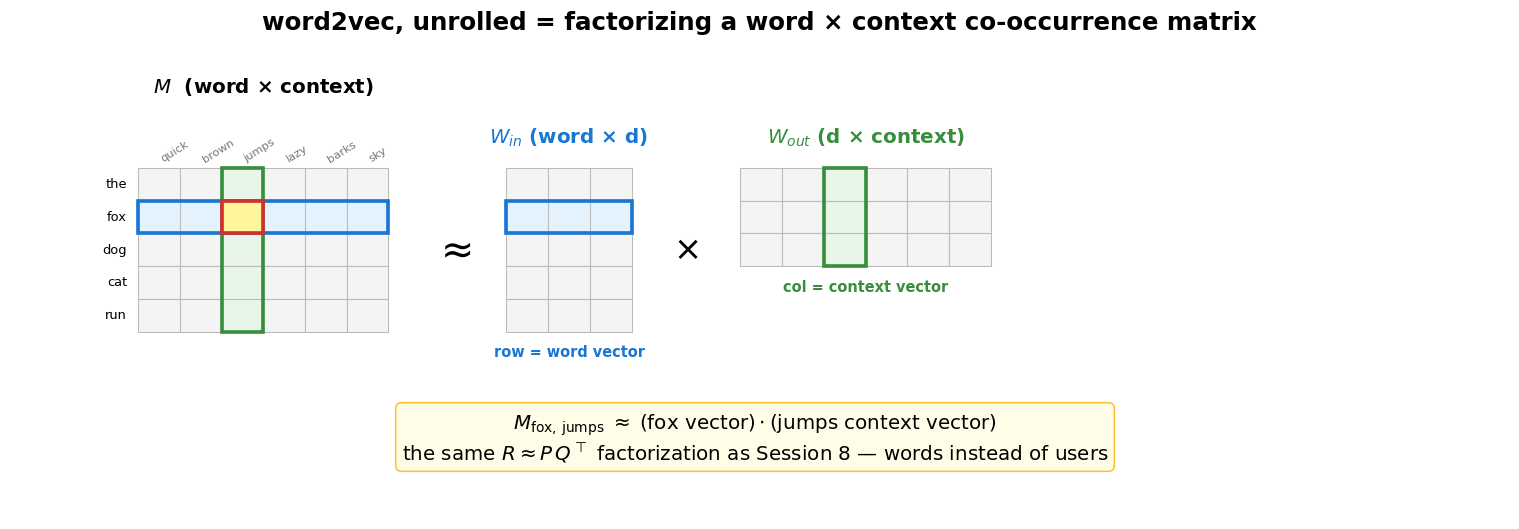

In [11]:
# The word x context co-occurrence matrix M, factorized into W_in (word vectors) and W_out (context vectors).
from matplotlib.patches import Rectangle
BLUE, RED, GREEN = '#1976d2', '#d32f2f', '#388e3c'
fig, ax = plt.subplots(figsize=(14, 5.0)); ax.axis('off')
ax.set_xlim(0, 16.5); ax.set_ylim(2.7, 9.4)
cw = 0.46
words = ['the', 'fox', 'dog', 'cat', 'run']
ctxs  = ['quick', 'brown', 'jumps', 'lazy', 'barks', 'sky']
d = 3
w_hi, c_hi = 1, 2                                   # highlight 'fox' row and 'jumps' context column
ry = 7.6

def grid(x0, nr, nc, hi_row=None, hi_col=None, rc=BLUE, cc=GREEN):
    for r in range(nr):
        for c in range(nc):
            fc = '#f4f4f4'
            if hi_row is not None and r == hi_row: fc = '#e3f2fd'
            if hi_col is not None and c == hi_col: fc = '#e8f5e9'
            ax.add_patch(Rectangle((x0+c*cw, ry-(r+1)*cw), cw, cw, facecolor=fc, edgecolor='#bbb', lw=0.7))
    if hi_row is not None:
        ax.add_patch(Rectangle((x0, ry-(hi_row+1)*cw), nc*cw, cw, fill=False, ec=rc, lw=2.4))
    if hi_col is not None:
        ax.add_patch(Rectangle((x0+hi_col*cw, ry-nr*cw), cw, nr*cw, fill=False, ec=cc, lw=2.4))

mx = 1.4
grid(mx, len(words), len(ctxs), hi_row=w_hi, hi_col=c_hi)
ax.add_patch(Rectangle((mx+c_hi*cw, ry-(w_hi+1)*cw), cw, cw, facecolor='#fff59d', edgecolor=RED, lw=2.4, zorder=4))
ax.text(mx+len(ctxs)*cw/2, ry+1.05, r'$M$  (word × context)', ha='center', fontweight='bold')
for r, w in enumerate(words):
    ax.text(mx-0.12, ry-(r+0.5)*cw, w, ha='right', va='center', fontsize=8.5)
for c, t in enumerate(ctxs):
    ax.text(mx+(c+0.5)*cw, ry+0.05, t, ha='left', va='bottom', fontsize=7.5, rotation=32, color='#777')

px = mx+len(ctxs)*cw+1.3
ax.text(px-0.6, ry-len(words)*cw/2, r'$\approx$', fontsize=26, ha='center', va='center')
grid(px, len(words), d, hi_row=w_hi)
ax.text(px+d*cw/2, ry+0.34, r'$W_{in}$ (word × d)', ha='center', fontweight='bold', color=BLUE)
ax.text(px+d*cw/2, ry-len(words)*cw-0.35, 'row = word vector', ha='center', color=BLUE, fontsize=9.5, fontweight='bold')

qx = px+d*cw+1.2
ax.text(qx-0.6, ry-len(words)*cw/2, r'$\times$', fontsize=22, ha='center', va='center')
grid(qx, d, len(ctxs), hi_col=c_hi)
ax.text(qx+len(ctxs)*cw/2, ry+0.34, r'$W_{out}$ (d × context)', ha='center', fontweight='bold', color=GREEN)
ax.text(qx+len(ctxs)*cw/2, ry-d*cw-0.35, 'col = context vector', ha='center', color=GREEN, fontsize=9.5, fontweight='bold')

ax.text(8.2, 3.5,
        r'$M_{\mathrm{fox,\,jumps}}\;\approx\;(\mathrm{fox\ vector})\cdot(\mathrm{jumps\ context\ vector})$'
        '\n'
        r'the same $R \approx P\,Q^{\top}$ factorization as Session 8 — words instead of users',
        ha='center', fontsize=13, bbox=dict(boxstyle='round', fc='#fffde7', ec='#fbc02d'))
ax.set_title('word2vec, unrolled = factorizing a word × context co-occurrence matrix', fontweight='bold')
plt.tight_layout(); plt.show()

## The payoff: neighbours & word arithmetic

- No need to train it yourself — **pretrained vectors** are a download away (here **GloVe**, trained
  on 6 billion words).
- **Nearby vectors = related words.** And relations become **offsets** you can add and subtract:
  **king − man + woman ≈ queen**.

nearest to “king”   : ['prince', 'queen', 'ii', 'emperor', 'son']
nearest to “coffee” : ['drink', 'drinks', 'wine', 'tea', 'beer']
analogy  king − man + woman       ≈  queen
analogy  paris − france + italy   ≈  rome
analogy  walked − walk + swim     ≈  swam


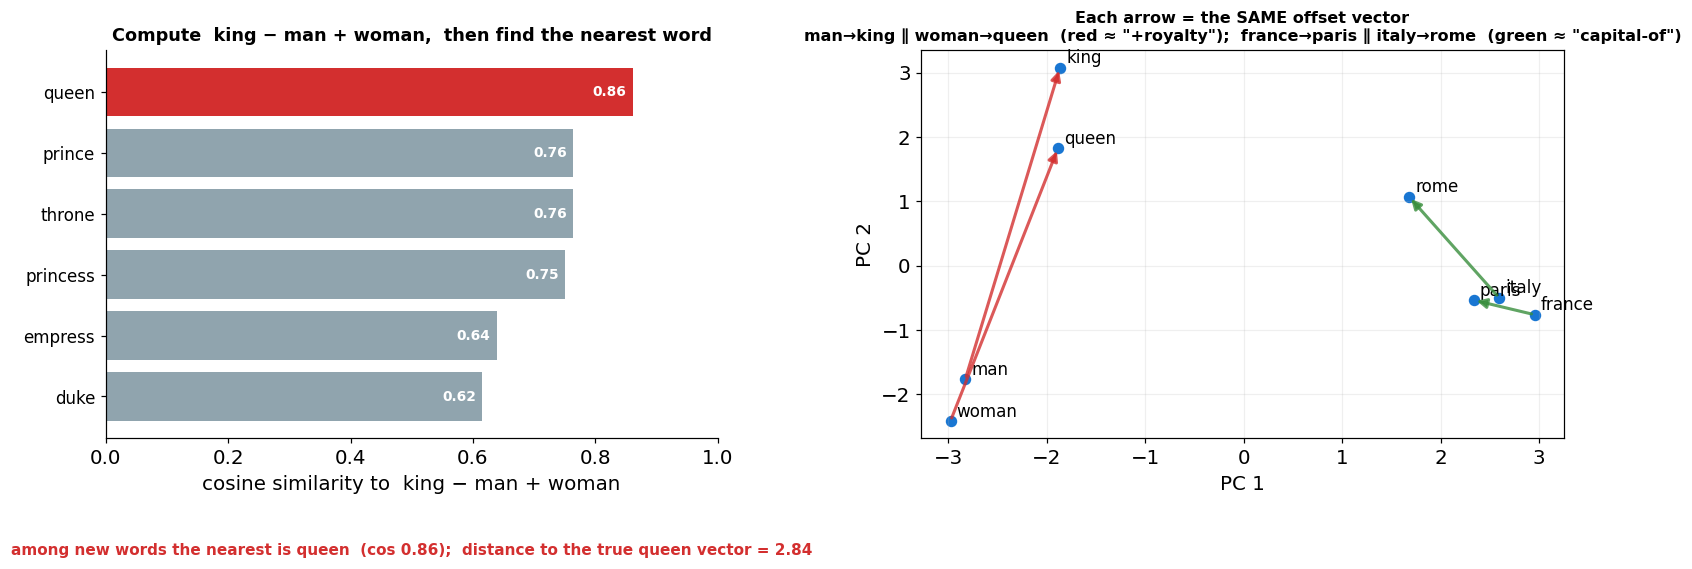

In [12]:
# Pretrained vectors (GloVe, 50-d, cached). Two classic payoffs: nearest neighbours + analogies.
import gensim.downloader as api
glove = api.load('glove-wiki-gigaword-50')          # cached -> instant

print('nearest to “king”   :', [w for w, _ in glove.most_similar('king', topn=5)])
print('nearest to “coffee” :', [w for w, _ in glove.most_similar('coffee', topn=5)])
for pos, neg, q in [(['king', 'woman'], ['man'], 'king − man + woman'),
                    (['paris', 'italy'], ['france'], 'paris − france + italy'),
                    (['walked', 'swim'], ['walk'], 'walked − walk + swim')]:
    ans = glove.most_similar(positive=pos, negative=neg, topn=1)[0][0]
    print(f'analogy  {q:24s} ≈  {ans}')

# Left: the analogy as actual arithmetic with numbers. Right: in 2-D, each arrow is the SAME offset vector.
from sklearn.decomposition import PCA
cos = lambda a, b: float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))
pred = glove['king'] - glove['man'] + glove['woman']          # the analogy vector
cand = ['queen', 'princess', 'prince', 'throne', 'duke', 'empress']   # candidates (inputs excluded)
sims = sorted(((w, cos(pred, glove[w])) for w in cand), key=lambda t: t[1])
qcos = cos(pred, glove['queen']); qdist = float(np.linalg.norm(pred - glove['queen']))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 5.6), gridspec_kw={'width_ratios': [1, 1.05]})
labels = [w for w, _ in sims]; vals = [s for _, s in sims]
axL.barh(range(len(vals)), vals, color=['#d32f2f' if w == 'queen' else '#90a4ae' for w in labels])
axL.set_yticks(range(len(labels))); axL.set_yticklabels(labels, fontsize=11)
for i, v in enumerate(vals):
    axL.text(v - 0.01, i, f'{v:.2f}', va='center', ha='right', color='white', fontweight='bold', fontsize=9)
axL.set_xlabel('cosine similarity to  king − man + woman'); axL.set_xlim(0, 1.0)
axL.set_title('Compute  king − man + woman,  then find the nearest word', fontsize=11.5, fontweight='bold')
axL.spines[['top', 'right']].set_visible(False)
axL.text(0.5, -0.30, f'among new words the nearest is queen  (cos {qcos:.2f});  '
         f'distance to the true queen vector = {qdist:.2f}',
         transform=axL.transAxes, ha='center', fontsize=10, color='#d32f2f', fontweight='bold')

words = ['king', 'queen', 'man', 'woman', 'france', 'paris', 'italy', 'rome']
X = np.array([glove[w] for w in words]); P2 = PCA(n_components=2).fit_transform(X)
axR.scatter(P2[:, 0], P2[:, 1], s=42, color='#1976d2')
for (x, y), w in zip(P2, words):
    axR.annotate(w, (x, y), fontsize=11, xytext=(4, 3), textcoords='offset points')
for a, b, c in [('man', 'king', '#d32f2f'), ('woman', 'queen', '#d32f2f'),
                ('france', 'paris', '#388e3c'), ('italy', 'rome', '#388e3c')]:
    i, j = words.index(a), words.index(b)
    axR.annotate('', xy=P2[j], xytext=P2[i], arrowprops=dict(arrowstyle='-|>', color=c, lw=2, alpha=0.8))
axR.set_title('Each arrow = the SAME offset vector\n'
              'man→king ∥ woman→queen  (red ≈ "+royalty");  france→paris ∥ italy→rome  (green ≈ "capital-of")',
              fontsize=10.5, fontweight='bold')
axR.grid(alpha=0.2); axR.set_xlabel('PC 1'); axR.set_ylabel('PC 2')
plt.tight_layout(); plt.show()

## The catch: one word → **one** vector

word2vec gives every word a *single* fixed vector. But meaning depends on **context**:

- *"sat on the river **bank**"*  🌊
- *"deposited cash at the **bank**"*  💰

word2vec blends both senses into one blurry point. Worse, it has **no vector for a sentence** —
averaging word vectors throws away word order entirely (*"dog bites man" = "man bites dog"*).

**We need vectors that change with context.** Enter the Transformer.

## BERT: what it does and how it was trained

- BERT reads the **whole sentence at once** (not left-to-right) and gives **every token its own
  context-dependent vector**.
- **Training objective — masked language modeling:** hide ~15% of the tokens and predict each one from
  the **rest of the sentence**, using both left and right context. No human labels needed.
- *Plus a small **next-sentence-prediction** task: does sentence B follow sentence A?*
- The masked-word prediction is only the **training signal**; at the end we keep **one contextual
  vector per token** (a sentence vector = **pool** those token vectors, e.g. their mean).

<small>*Diagrams in this section are schematic, for intuition — not the full architecture.*</small>

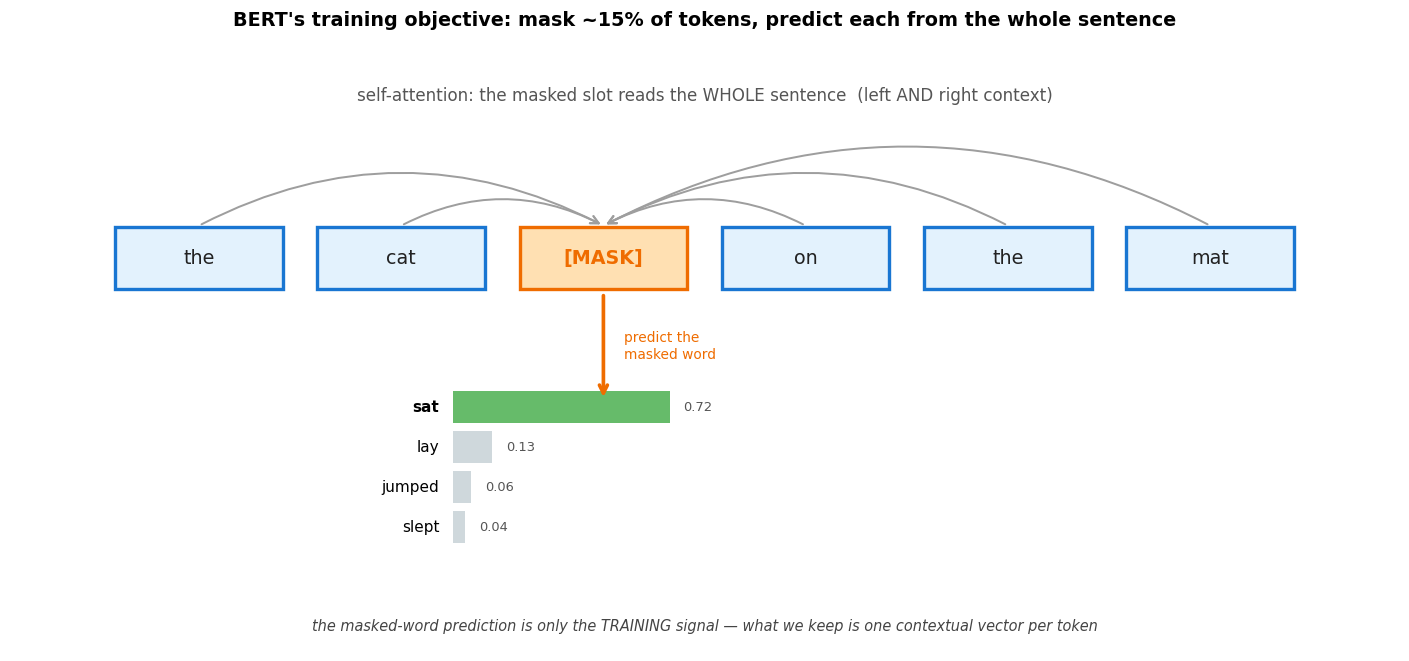

In [13]:
# BERT's pretraining objective: Masked Language Modeling. Hide a token, predict it from the WHOLE
# sentence (both left and right context) — this is how BERT learns contextual vectors.
fig, ax = plt.subplots(figsize=(13, 6.2)); ax.axis('off')
ax.set_xlim(0, 12); ax.set_ylim(0, 8)
toks = ['the', 'cat', '[MASK]', 'on', 'the', 'mat']
n = len(toks); bw, gap = 1.45, 0.30
x0 = (12 - (n*bw + (n-1)*gap)) / 2
ytok = 4.7
cx = [x0 + i*(bw+gap) + bw/2 for i in range(n)]
mask_i = 2
for i, t in enumerate(toks):
    x = cx[i] - bw/2; masked = (i == mask_i)
    fc = '#ffe0b2' if masked else '#e3f2fd'; ec = '#ef6c00' if masked else '#1976d2'
    ax.add_patch(plt.Rectangle((x, ytok), bw, 0.8, facecolor=fc, edgecolor=ec, lw=2.2))
    ax.text(cx[i], ytok+0.4, t, ha='center', va='center', fontsize=12.5,
            fontweight='bold' if masked else 'normal', color=ec if masked else '#222')
# bidirectional context arrows curving above into the mask
for i in range(n):
    if i == mask_i: continue
    rad = -0.26 if i < mask_i else 0.26
    ax.annotate('', xy=(cx[mask_i], ytok+0.82), xytext=(cx[i], ytok+0.82),
                arrowprops=dict(arrowstyle='->', color='#9e9e9e', lw=1.3,
                                connectionstyle=f'arc3,rad={rad}'))
ax.text(6, ytok+2.45, 'self-attention: the masked slot reads the WHOLE sentence  (left AND right context)',
        ha='center', fontsize=11, color='#555')
# prediction: arrow down from the mask to a small bar chart of guesses
ax.annotate('', xy=(cx[mask_i], 3.25), xytext=(cx[mask_i], ytok-0.05),
            arrowprops=dict(arrowstyle='->', color='#ef6c00', lw=2.4))
ax.text(cx[mask_i]+0.18, 3.95, 'predict the\nmasked word', ha='left', va='center', fontsize=9, color='#ef6c00')
guesses = [('sat', 0.72), ('lay', 0.13), ('jumped', 0.06), ('slept', 0.04)]
gw = 2.6; top = 2.95
for j, (w, p) in enumerate(guesses):
    yy = top - j*0.52
    ax.add_patch(plt.Rectangle((cx[mask_i]-gw/2, yy), p*gw, 0.42,
                               facecolor='#66bb6a' if j == 0 else '#cfd8dc', edgecolor='none'))
    ax.text(cx[mask_i]-gw/2-0.12, yy+0.21, w, ha='right', va='center', fontsize=10,
            fontweight='bold' if j == 0 else 'normal')
    ax.text(cx[mask_i]-gw/2+p*gw+0.12, yy+0.21, f'{p:.2f}', ha='left', va='center', fontsize=8.5, color='#555')
ax.set_title("BERT's training objective: mask ~15% of tokens, predict each from the whole sentence",
             fontsize=12.5, fontweight='bold')
ax.text(6, 0.25, 'the masked-word prediction is only the TRAINING signal — what we keep is one contextual vector per token',
        ha='center', fontsize=9.5, color='#444', style='italic')
plt.tight_layout(); plt.show()

## BERT: pretraining vs. fine-tuning

<div style="text-align:center; max-width:860px; margin:0.3em auto 0;">

</div>

<p style="text-align:center; color:#555; font-size:0.8em; margin:0.3em 0 0;">Same encoder, reused: pretrain with masked-LM (+ next-sentence prediction), then transfer the weights and swap in a task head. Schematic, not the full architecture.</p>

## How a sentence enters the model

<div style="text-align:center; max-width:860px; margin:0.3em auto 0;">

</div>

<p style="text-align:center; color:#555; font-size:0.8em; margin:0.3em 0 0;">Each token id looks up a row of the embedding matrix; the rows stack into the T×d input matrix (T tokens, each a d-dim vector) that enters the first transformer block.</p>

## Each token becomes a query, a key and a value

<div style="text-align:center; max-width:860px; margin:0.3em auto 0;">

</div>

<p style="text-align:center; color:#555; font-size:0.8em; margin:0.3em 0 0;">One token vector × three learned matrices (W_Q, W_K, W_V) → its query, key and value.</p>

## Attention is a soft dictionary lookup

<div style="text-align:center; max-width:860px; margin:0.3em auto 0;">

</div>

<p style="text-align:center; color:#555; font-size:0.8em; margin:0.3em 0 0;">The query is matched against every key to get weights; the new vector is the weighted sum of the values (line thickness = weight).</p>

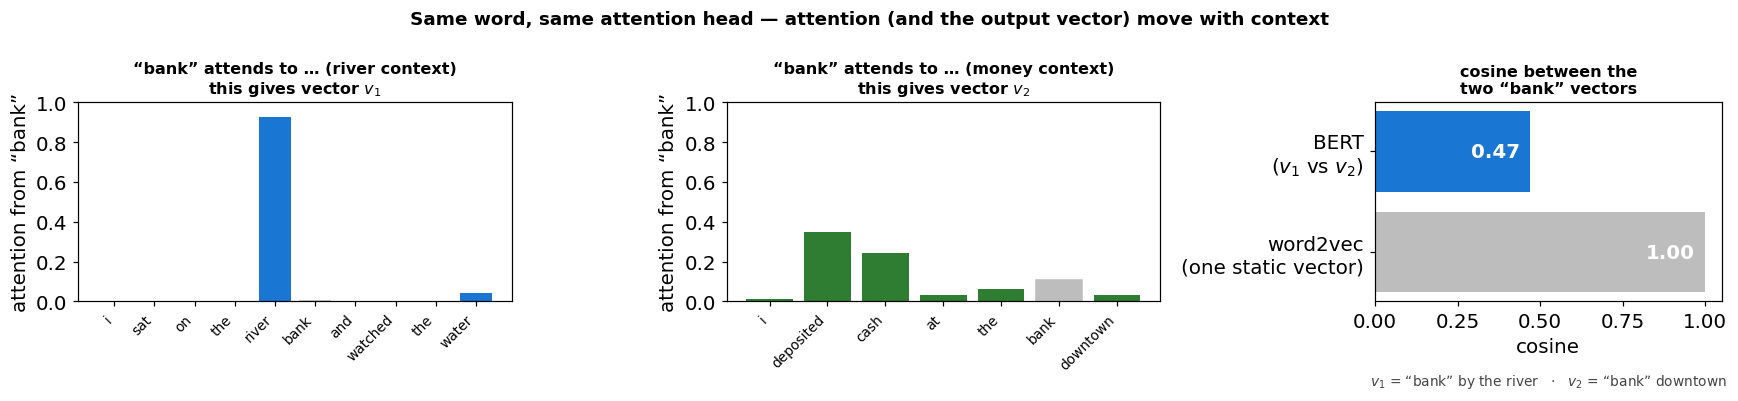

word2vec: both “bank”s identical (cos 1.00).  BERT: cos = 0.47 — context split them.


In [14]:
# Real BERT (bert-base-uncased, cached). One attention head's weights shift with context,
# and the resulting two "bank" vectors are genuinely different.
import torch, warnings
from transformers import AutoTokenizer, AutoModel, logging as hf_logging
hf_logging.set_verbosity_error(); hf_logging.disable_progress_bar()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    tok = AutoTokenizer.from_pretrained('bert-base-uncased')
    bert = AutoModel.from_pretrained('bert-base-uncased', output_attentions=True,
                                     attn_implementation='eager').eval()   # eager -> no attn warning
LAYER, HEAD = 2, 10                                  # one interpretable head among the 12×12

def analyze(sentence):
    enc = tok(sentence, return_tensors='pt')
    toks = tok.convert_ids_to_tokens(enc['input_ids'][0])
    with torch.no_grad():
        out = bert(**enc)
    b = toks.index('bank')
    vec = out.last_hidden_state[0][b].numpy()                       # contextual "bank" vector
    att = out.attentions[LAYER][0, HEAD, b].numpy()                 # what "bank" attends to
    keep = [i for i, t in enumerate(toks) if t not in ('[CLS]', '[SEP]')]
    return [toks[i] for i in keep], att[keep], vec

t1, a1, v1 = analyze('i sat on the river bank and watched the water')
t2, a2, v2 = analyze('i deposited cash at the bank downtown')
cos = lambda a, b: float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), gridspec_kw={'width_ratios': [1, 1, 0.8]})
for ax, (toks, att, ttl, tag, c) in zip(axes[:2],
        [(t1, a1, 'river context', 'v_1', '#1976d2'), (t2, a2, 'money context', 'v_2', '#2e7d32')]):
    bars = ax.bar(range(len(toks)), att, color=c)
    bars[toks.index('bank')].set_color('#bdbdbd')          # 'bank' itself, for reference
    ax.set_xticks(range(len(toks))); ax.set_xticklabels(toks, rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0, 1); ax.set_ylabel('attention from “bank”')
    ax.set_title(f'“bank” attends to … ({ttl})\nthis gives vector ${tag}$', fontsize=10.5, fontweight='bold')
axc = axes[2]
axc.barh(['word2vec\n(one static vector)', 'BERT\n($v_1$ vs $v_2$)'], [1.0, cos(v1, v2)], color=['#bdbdbd', '#1976d2'])
axc.set_xlim(0, 1.05); axc.set_xlabel('cosine')
axc.set_title('cosine between the\ntwo “bank” vectors', fontsize=10.5, fontweight='bold')
for y, v in zip([0, 1], [1.0, cos(v1, v2)]):
    axc.text(v - 0.03, y, f'{v:.2f}', va='center', ha='right', color='white', fontweight='bold')
axc.text(0.5, -0.42, '$v_1$ = “bank” by the river   ·   $v_2$ = “bank” downtown',
         transform=axc.transAxes, ha='center', fontsize=9, color='#444')
plt.suptitle('Same word, same attention head — attention (and the output vector) move with context',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'word2vec: both “bank”s identical (cos 1.00).  BERT: cos = {cos(v1, v2):.2f} — context split them.')

## But raw BERT is *bad* at sentence similarity

Tempting plan: to compare two sentences, average BERT's token vectors (or take the `[CLS]` token) and
use cosine. **It works poorly** — vanilla BERT was never trained so that *cosine distance = meaning*.
Unrelated sentences often score deceptively high.

**Sentence-Transformers (SBERT)** fix this with **contrastive fine-tuning**:

- feed **pairs** of sentences through the same BERT (a *siamese* setup)
- **pull** paraphrases together, **push** unrelated sentences apart

The loss is just **softmax cross-entropy** over the batch: among the anchor $\vec a$ and all candidate
sentences $\vec s_j$, make the **true match $\vec p$ the most similar**.

$$\mathcal{L} \;=\; -\log \frac{e^{\cos(\vec a,\vec p)}}{\sum_j e^{\cos(\vec a,\vec s_j)}}$$

Softmax the cosines → a probability per candidate → push the probability of the **right pair toward 1**.

Now one forward pass → **one sentence vector**, and **cosine actually means similarity**.

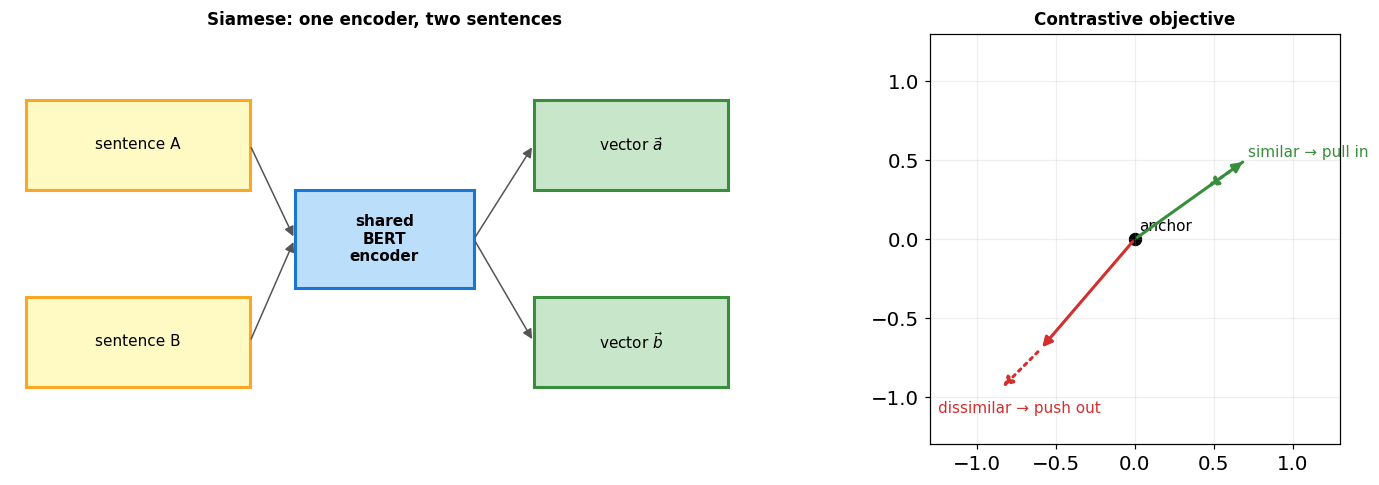

In [15]:
# Contrastive idea: same encoder on a pair, pull similar together / push dissimilar apart.
fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 4.6))
axA.axis('off'); axA.set_xlim(0, 1); axA.set_ylim(0, 1)
def b(ax, x, y, w, h, t, fc, ec, fs=10, fw='normal'):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec, lw=2, zorder=2))
    ax.text(x + w/2, y + h/2, t, ha='center', va='center', fontsize=fs, fontweight=fw, zorder=3)
b(axA, 0.02, 0.62, 0.30, 0.22, 'sentence A', '#fff9c4', '#f9a825')
b(axA, 0.02, 0.14, 0.30, 0.22, 'sentence B', '#fff9c4', '#f9a825')
b(axA, 0.38, 0.38, 0.24, 0.24, 'shared\nBERT\nencoder', '#bbdefb', '#1976d2', fw='bold')
b(axA, 0.70, 0.62, 0.26, 0.22, 'vector $\\vec a$', '#c8e6c9', '#388e3c')
b(axA, 0.70, 0.14, 0.26, 0.22, 'vector $\\vec b$', '#c8e6c9', '#388e3c')
for y in (0.73, 0.25):
    axA.annotate('', xy=(0.38, 0.50), xytext=(0.32, y), arrowprops=dict(arrowstyle='-|>', color='#555'))
    axA.annotate('', xy=(0.70, y), xytext=(0.62, 0.50), arrowprops=dict(arrowstyle='-|>', color='#555'))
axA.set_title('Siamese: one encoder, two sentences', fontsize=11, fontweight='bold')

# right: the training objective in vector space
axB.set_xlim(-1.3, 1.3); axB.set_ylim(-1.3, 1.3); axB.set_aspect('equal'); axB.grid(alpha=0.2)
axB.scatter([0], [0], s=60, color='black'); axB.text(0.03, 0.05, 'anchor', fontsize=10)
axB.annotate('', xy=(0.7, 0.5), xytext=(0, 0), arrowprops=dict(arrowstyle='-|>', color='#388e3c', lw=2))
axB.annotate('', xy=(0.45, 0.32), xytext=(0.7, 0.5),
             arrowprops=dict(arrowstyle='-|>', color='#388e3c', lw=2, ls=':'))
axB.text(0.72, 0.52, 'similar → pull in', color='#388e3c', fontsize=10)
axB.annotate('', xy=(-0.6, -0.7), xytext=(0, 0), arrowprops=dict(arrowstyle='-|>', color='#d32f2f', lw=2))
axB.annotate('', xy=(-0.85, -0.95), xytext=(-0.6, -0.7),
             arrowprops=dict(arrowstyle='-|>', color='#d32f2f', lw=2, ls=':'))
axB.text(-1.25, -1.1, 'dissimilar → push out', color='#d32f2f', fontsize=10)
axB.set_title('Contrastive objective', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

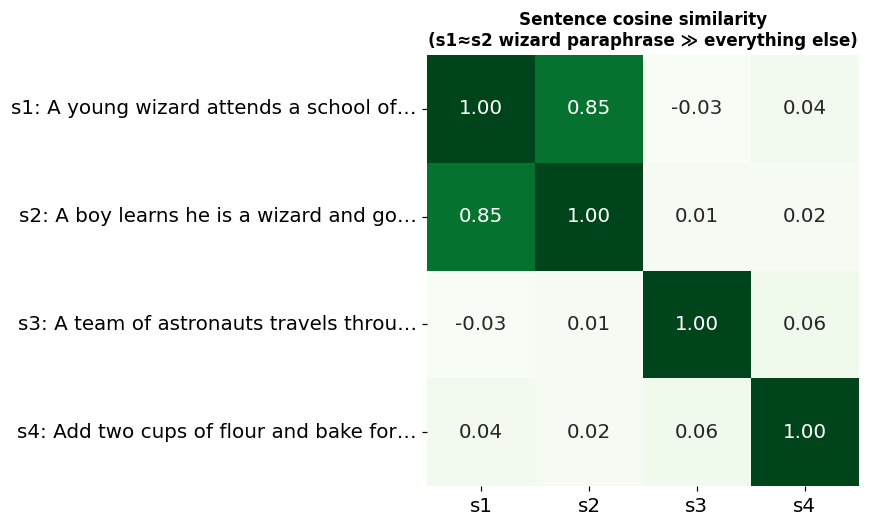

wizard paraphrase  s1·s2 = 0.85   vs   wizard·recipe  s1·s4 = 0.04


In [16]:
# SBERT in action: cosine between sentence vectors actually tracks meaning. (all-MiniLM-L6-v2, cached.)
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
sbert = SentenceTransformer('all-MiniLM-L6-v2')

sents = ['A young wizard attends a school of magic.',
         'A boy learns he is a wizard and goes to a magic school.',   # paraphrase of #1
         'A team of astronauts travels through a wormhole in space.',
         'Add two cups of flour and bake for thirty minutes.']
E = sbert.encode(sents, normalize_embeddings=True)
S = cosine_similarity(E)

import seaborn as sns
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(S, annot=True, fmt='.2f', cmap='Greens', vmin=0, vmax=1, square=True,
            xticklabels=[f's{i+1}' for i in range(4)],
            yticklabels=[f's{i+1}: {s[:34]}…' for i, s in enumerate(sents)], cbar=False, ax=ax)
ax.set_title('Sentence cosine similarity\n(s1≈s2 wizard paraphrase ≫ everything else)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'wizard paraphrase  s1·s2 = {S[0,1]:.2f}   vs   wizard·recipe  s1·s4 = {S[0,3]:.2f}')

## Embedding our movies: text → vectors → a map

Now point SBERT at the **MovieLens** catalogue. Each movie's description becomes a 384-dim vector.
Project to 2-D with **PCA** (Session 8) and colour by genre: unlike the *collaborative* embeddings
(which clustered by viewing taste), **text** embeddings cluster by **theme/genre** — because that's
what the words describe.

In [17]:
# Loading a sentence-embedding model and embedding text is just two steps (the same .encode() API
# as the sentence demo above).
from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer('all-MiniLM-L6-v2')         # download once, then cached locally

# mv.text = each popular movie's description; encode -> ONE 384-d vector per movie
EMB = sbert.encode(mv.text.tolist(), normalize_embeddings=True, show_progress_bar=False)
print(EMB.shape)                                         # (n_movies, 384) — a vector per movie

(450, 384)


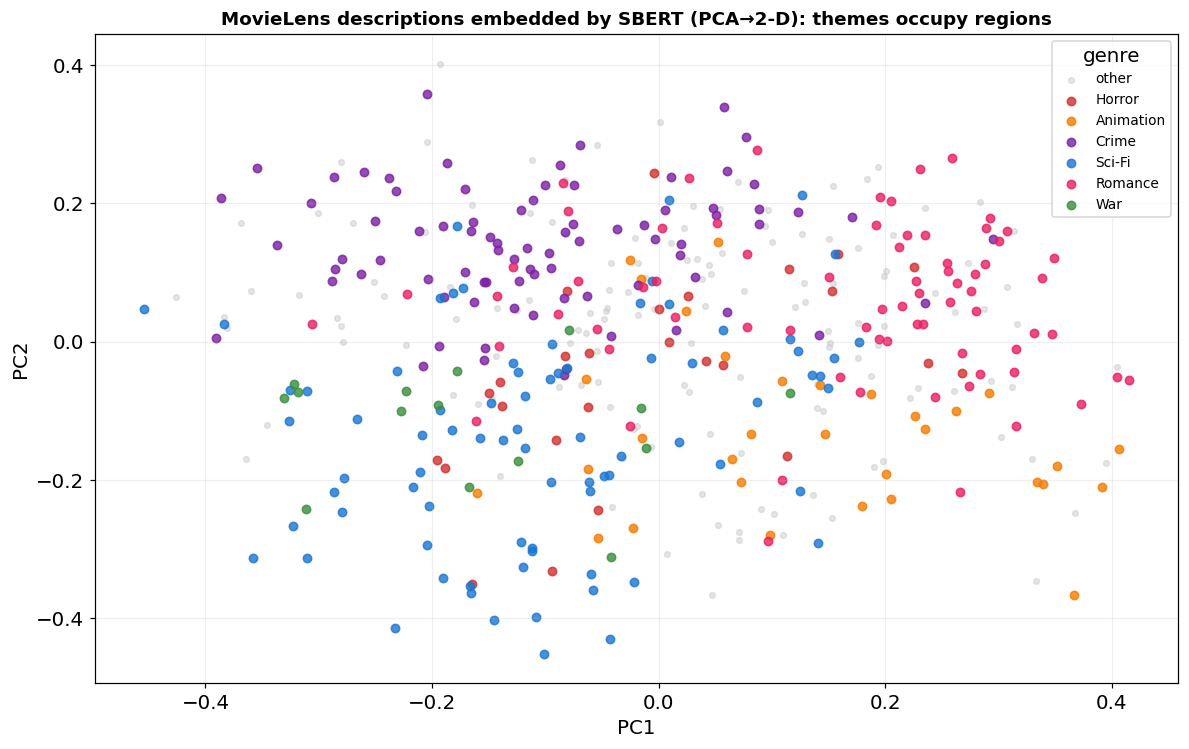

In [18]:
# Project those SBERT vectors to 2-D with PCA, coloured by genre membership.
from sklearn.decomposition import PCA
emb = EMB                                                # the embeddings from the cell above

P2 = PCA(n_components=2).fit_transform(emb)
# Colour by the most DISTINCTIVE genre a movie belongs to (checked in this order).
# (The first-listed "primary" genre is alphabetical — it would file Toy Story under Adventure.)
themes = [('Horror', '#d32f2f'), ('Animation', '#f57c00'), ('Crime', '#7b1fa2'),
          ('Sci-Fi', '#1976d2'), ('Romance', '#e91e63'), ('War', '#388e3c')]
theme_of = np.full(len(mv), -1)
for k, (g, _) in enumerate(themes):
    hit = (theme_of == -1) & mv.genres.str.contains(g, regex=False)
    theme_of[hit] = k
fig, ax = plt.subplots(figsize=(11, 7))
rest = theme_of == -1
ax.scatter(P2[rest, 0], P2[rest, 1], s=14, color='#cccccc', alpha=0.5, label='other')
for k, (g, col) in enumerate(themes):
    mk = theme_of == k
    ax.scatter(P2[mk, 0], P2[mk, 1], s=30, color=col, alpha=0.8, label=g)
ax.legend(loc='best', fontsize=9, title='genre')
ax.set_title('MovieLens descriptions embedded by SBERT (PCA→2-D): themes occupy regions',
             fontsize=12, fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

In [19]:
# Pick a movie, rank the rest by cosine in embedding space -> "more like this".
from sklearn.metrics.pairwise import cosine_similarity
def more_like(title_sub, k=5):
    i = mv.index[mv.title.str.contains(title_sub, case=False, regex=False)][0]
    sims = cosine_similarity(EMB[i:i+1], EMB)[0]
    order = np.argsort(-sims)[1:k+1]
    print(f'Because you liked  «{mv.title.iloc[i]}»:')
    for j in order:
        print(f'   {sims[j]:.2f}   {mv.title.iloc[j]}   [{mv.primary_genre.iloc[j]}]')
    print()

more_like('Toy Story')
more_like('Matrix')

Because you liked  «Toy Story (1995)»:
   0.76   Toy Story 3 (2010)   [Adventure]
   0.74   Toy Story 2 (1999)   [Adventure]
   0.35   Back to the Future Part II (1989)   [Adventure]
   0.34   A.I. Artificial Intelligence (2001)   [Adventure]
   0.31   Jumanji (1995)   [Adventure]

Because you liked  «Matrix, The (1999)»:
   0.58   Matrix Reloaded, The (2003)   [Action]
   0.47   The Imitation Game (2014)   [Drama]
   0.46   Matrix Revolutions, The (2003)   [Action]
   0.41   2001: A Space Odyssey (1968)   [Adventure]
   0.39   Beautiful Mind, A (2001)   [Drama]



## Cold-start, solved: a brand-new movie nobody has rated

Collaborative filtering is stuck on a brand-new title — **no ratings → no vector**. But text
embeddings are **inductive**: feed *any* description through SBERT and you get a vector *immediately*,
placeable next to everything else. Take a **2024 release** — well after MovieLens-small ends (~2018), so
it is genuinely unseen — embed its plot, and find its nearest catalogue neighbours:

In [20]:
# A real, recent movie (Dune: Part Two, 2024) — NOT in MovieLens — placed from its plot text alone.
# No ratings needed: the description's vector lands next to similar catalogue movies.
from sklearn.metrics.pairwise import cosine_similarity
new_blurb = ('On a harsh desert planet, a young hero rises to lead a rebellion against an evil '
             'galactic empire — a science-fiction space epic of starships, prophecy and interplanetary war.')
q = SentenceTransformer('all-MiniLM-L6-v2').encode([new_blurb], normalize_embeddings=True)
sims = cosine_similarity(q, EMB)[0]
print(f'New (unrated, 2024) movie:\n  “{new_blurb}”\n\nNearest movies in the catalogue:')
for j in np.argsort(-sims)[:5]:
    print(f'   {sims[j]:.2f}   {mv.title.iloc[j]}   [{mv.primary_genre.iloc[j]}]')

New (unrated, 2024) movie:
  “On a harsh desert planet, a young hero rises to lead a rebellion against an evil galactic empire — a science-fiction space epic of starships, prophecy and interplanetary war.”

Nearest movies in the catalogue:
   0.47   Star Wars: Episode III - Revenge of the Sith (2005)   [Action]
   0.44   Star Wars: Episode V - The Empire Strikes Back (1980)   [Action]
   0.41   Star Trek (2009)   [Action]
   0.40   300 (2007)   [Action]
   0.40   Star Wars: Episode VI - Return of the Jedi (1983)   [Action]


## Storing & searching vectors at scale: a vector database

We have a few hundred vectors today, millions in production. A **vector database** stores embeddings
and answers *"give me the nearest k to this query vector"* fast. **ChromaDB** does it in ~5 lines:

```python
import chromadb
client = chromadb.Client()
col = client.create_collection("movies")
col.add(ids=..., embeddings=..., documents=..., metadatas=...)
col.query(query_embeddings=..., n_results=5)
```

Under the hood it doesn't compare your query to *every* vector — that's **brute force** and too slow.
It builds an **approximate nearest-neighbour** index: **HNSW**.

<div style="text-align:center; max-width:900px; margin:0.2em auto 0;">
<img alt="The whole pipeline: movie plots and the user query share one embedding model; document vectors live in the database, the query vector is matched against them, top-k returned." style="width:100%;height:auto;display:block;margin:0 auto" src=""/>
</div>

<p style="text-align:center; color:#555; font-size:0.8em; margin:0.3em 0 0;">The whole pipeline: movie plots and the user query share one embedding model; document vectors live in the database, the query vector is matched against them, top-k returned.</p>

In [21]:
# Load our movie vectors into ChromaDB (in-memory). We pass our own SBERT vectors directly.
import chromadb
client = chromadb.Client()
try:
    client.delete_collection('movies')
except Exception:
    pass
col = client.create_collection('movies', metadata={'hnsw:space': 'cosine'})
col.add(ids=[str(m) for m in mv.movieId],
        embeddings=[e.tolist() for e in EMB],
        documents=mv.text.tolist(),
        metadatas=[{'title': t, 'genre': g} for t, g in zip(mv.title, mv.primary_genre)])
print(f'stored {col.count()} movie vectors in ChromaDB (cosine / HNSW index)')

stored 450 movie vectors in ChromaDB (cosine / HNSW index)


## Why HNSW beats brute force

**Brute force:** compare the query to **all N** vectors → exact, but $O(N)$ per query. Hopeless at
millions × many queries/sec.

**HNSW** (Hierarchical Navigable Small World) builds a **multi-layer proximity graph**:

- sparse top layers = "express lanes" for big jumps across the space
- dense bottom layer = fine local steps
- search = **greedy hop** toward the query, descending layers — only $O(\log N)$ nodes visited

You trade a tiny bit of recall for **orders-of-magnitude** speed. That's the engine inside Chroma,
FAISS, pgvector, Pinecone, …

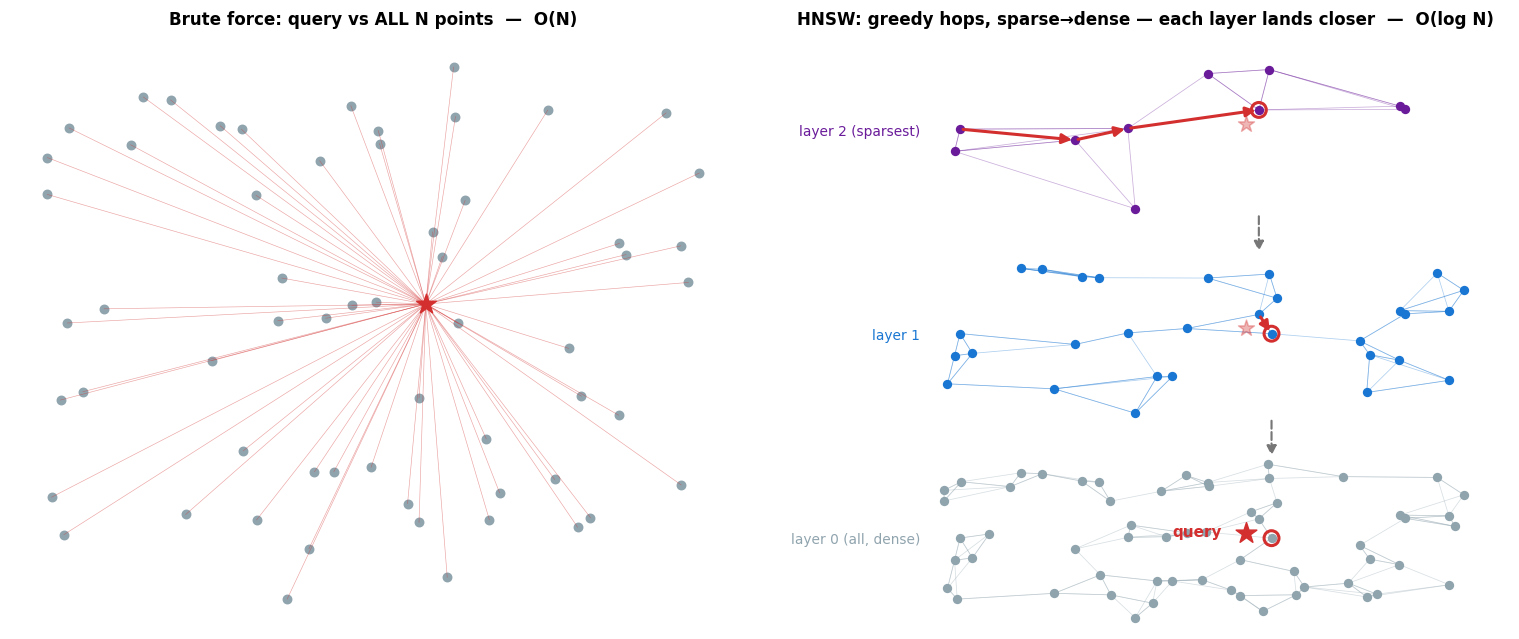

In [22]:
# Left: brute force touches every point. Right: HNSW makes a GREEDY walk that lands closer each layer.
fig, (axB, axH) = plt.subplots(1, 2, figsize=(14, 6.0))
rng = np.random.default_rng(7)
pts = rng.uniform(0, 1, size=(60, 2)); q = np.array([0.58, 0.55])   # query in the unit square

# --- left: brute force compares against ALL points ---
axB.scatter(pts[:, 0], pts[:, 1], s=30, color='#90a4ae')
for p in pts:
    axB.plot([q[0], p[0]], [q[1], p[1]], color='#d32f2f', lw=0.4, alpha=0.45)
axB.scatter(*q, s=180, color='#d32f2f', marker='*', zorder=5)
axB.set_title('Brute force: query vs ALL N points  —  O(N)', fontsize=11, fontweight='bold')
axB.set_xlim(-0.05, 1.05); axB.set_ylim(-0.05, 1.05); axB.axis('off')

# --- right: stacked layers; a greedy walk that visibly converges toward the query each layer ---
def _d(a, b): return np.linalg.norm(a - b, axis=-1)

def greedy_path(P, start, qp, max_hops=6):
    # from `start`, repeatedly hop to the nearest node that is strictly closer to the query,
    # until none improves (local minimum = this layer's landing node).
    cur = start; path = [cur]; seen = {cur}
    for _ in range(max_hops):
        dcur = np.linalg.norm(P[cur] - qp)
        cand = [i for i in range(len(P)) if i not in seen and np.linalg.norm(P[i] - qp) < dcur]
        if not cand: break
        cur = min(cand, key=lambda i: np.linalg.norm(P[i] - P[cur]))   # nearest improving neighbour
        path.append(cur); seen.add(cur)
    return path

layers = [(np.arange(0, 60, 6), 2.15, 2.95, '#6a1b9a', 'layer 2 (sparsest)'),   # 10 nodes
          (np.arange(0, 60, 2), 1.10, 1.90, '#1976d2', 'layer 1'),               # 30 nodes
          (np.arange(0, 60, 1), 0.05, 0.85, '#90a4ae', 'layer 0 (all, dense)')]  # 60 nodes

def band_xy(idx, y0, y1):
    sub = pts[idx]; return np.column_stack([sub[:, 0], y0 + (y1 - y0) * sub[:, 1]])

prev_landing = np.array([0.08, 0.9])                 # entry point: far corner of the data
for k, (idx, y0, y1, color, label) in enumerate(layers):
    sub = pts[idx]; XY = band_xy(idx, y0, y1)
    for a in XY:                                      # small-world links: each node to its nearest few
        nn = np.argsort(_d(XY, a))[1:4]
        for j in nn:
            axH.plot([a[0], XY[j, 0]], [a[1], XY[j, 1]], color=color, lw=0.5, alpha=0.35)
    axH.scatter(XY[:, 0], XY[:, 1], s=26, color=color, zorder=3)
    axH.text(-0.04, (y0 + y1) / 2, label, ha='right', va='center', fontsize=9, color=color)
    start = int(np.argmin(_d(sub, prev_landing)))     # enter where we dropped in from above
    path = greedy_path(sub, start, q)
    for a, b in zip(path[:-1], path[1:]):
        axH.annotate('', xy=XY[b], xytext=XY[a], arrowprops=dict(arrowstyle='-|>', color='#d32f2f', lw=2.0))
    land = path[-1]
    axH.scatter(*XY[land], s=95, facecolor='none', edgecolor='#d32f2f', lw=2.0, zorder=4)  # landing node
    axH.scatter([q[0]], [y0 + (y1 - y0) * q[1]], s=120, color='#d32f2f', marker='*', alpha=0.35, zorder=5)
    if k < len(layers) - 1:                           # dashed drop to the next (denser) layer
        ny1 = layers[k + 1][2]
        axH.annotate('', xy=(XY[land][0], ny1 + 0.02), xytext=(XY[land][0], y0 - 0.02),
                     arrowprops=dict(arrowstyle='-|>', color='#777', lw=1.4, ls='--'))
    prev_landing = sub[land]

axH.scatter([q[0]], [0.05 + 0.80 * q[1]], s=200, color='#d32f2f', marker='*', zorder=6)   # query, bottom
axH.text(q[0] - 0.045, 0.05 + 0.80 * q[1], 'query', color='#d32f2f', fontsize=10, fontweight='bold',
         ha='right', va='center')
axH.set_title('HNSW: greedy hops, sparse→dense — each layer lands closer  —  O(log N)',
              fontsize=11, fontweight='bold')
axH.set_xlim(-0.30, 1.08); axH.set_ylim(0, 3.05); axH.axis('off')
plt.tight_layout(); plt.show()

## Semantic search: type what you want, get movies

The payoff. Write a free-text wish — not a title, not a tag — embed it with the **same** SBERT model,
and ask ChromaDB for the nearest movie vectors. Meaning matches, not keywords.

In [23]:
# Free-text query -> embed -> ChromaDB nearest movies.
sbert = SentenceTransformer('all-MiniLM-L6-v2')
def search(query, k=5):
    qv = sbert.encode([query], normalize_embeddings=True)[0].tolist()
    res = col.query(query_embeddings=[qv], n_results=k)
    print(f'🔎  “{query}”')
    for doc_id, meta, dist in zip(res['ids'][0], res['metadatas'][0], res['distances'][0]):
        print(f'   sim {1 - dist:.2f}   {meta["title"]}   [{meta["genre"]}]')
    print()

search('a young hero learns magic at a wizard school')
search('a hacker discovers reality is a simulation')
search('a dark crime story about the mafia')

🔎  “a young hero learns magic at a wizard school”
   sim 0.48   Harry Potter and the Order of the Phoenix (2007)   [Adventure]
   sim 0.45   Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001)   [Adventure]
   sim 0.43   Wizard of Oz, The (1939)   [Adventure]
   sim 0.41   Breakfast Club, The (1985)   [Comedy]
   sim 0.37   Rushmore (1998)   [Comedy]

🔎  “a hacker discovers reality is a simulation”
   sim 0.52   Matrix, The (1999)   [Action]
   sim 0.48   Tron (1982)   [Action]
   sim 0.38   Truman Show, The (1998)   [Comedy]
   sim 0.37   Inception (2010)   [Action]
   sim 0.37   Total Recall (1990)   [Action]

🔎  “a dark crime story about the mafia”
   sim 0.58   Donnie Brasco (1997)   [Crime]
   sim 0.54   Departed, The (2006)   [Crime]
   sim 0.52   Goodfellas (1990)   [Crime]
   sim 0.51   L.A. Confidential (1997)   [Crime]
   sim 0.47   Godfather, The (1972)   [Crime]



## Key Takeaways

1. **Text → vectors.** Neural embeddings give *any* item a vector from its words — no ratings needed.
2. **word2vec** = factorize a word-co-occurrence matrix (same trick as Session 8's $R\approx PQ^T$);
   the hidden layer *is* the embedding — a pure **down-projection**, no activation.
3. **Static → contextual:** word2vec gives one fixed vector per word; **BERT** reads the whole sentence —
   trained by **masking words and predicting them** — and outputs a vector per word *in context* via self-attention.
4. **Contextual → comparable:** **Sentence-Transformers** fine-tune **contrastively** (softmax cross-entropy:
   pull true pairs together) so **cosine = meaning**; **pool** the token vectors into one sentence vector.
5. **Cold-start solved:** embed a brand-new description (e.g. a 2024 movie) and it lands right next to similar items.
6. **Vector DB (ChromaDB)** stores embeddings; **HNSW** searches them in $O(\log N)$ instead of brute-force $O(N)$.

## Where this goes next

- **Retrieval-Augmented Generation (RAG):** this exact pipeline — embed → vector DB → nearest-k — is
  how LLMs fetch relevant context before answering.
- **Multimodal & two-tower (Session 10):** the same idea embeds images, audio, users & items into *one*
  space — e.g. **CLIP** puts a movie's **poster** and its text in one shared space, trained the same
  contrastive way.
- **Practice:** generate text embeddings, test semantic similarity, build a ChromaDB recommender, and
  run the **cold-start** test — invent a new movie, find its neighbours.